# Equal-Volume Cylindrical Shell Theta Baseline

This baseline uses centered cylindrical shell bands with equal shell volume.

Each shell is defined by successive outer boundaries:
- `R_i = R_max * (i / n_shells)^(1/3)`
- `Z_i = Z_max * (i / n_shells)^(1/3)`

The target is `inside_shell`, meaning an event lies inside shell band `i` and outside shell band `i-1`.


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "prepare_resum_data.py").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT / "src" / "run_cnp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_cnp"))
if str(REPO_ROOT / "src" / "run_mfgp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_mfgp"))

from cnp_clean_pipeline import load_runtime_config, predict_cnp, train_cnp
from mfgp_clean_pipeline import run_mfgp_transform_suite

PREP_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "config" / "pipeline_config.json"
NOTEBOOK_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "config" / "runtime_notebook_config.json"
CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "settings_equal_volume_shell_minibatch.yaml"
VALIDATION_CONFIG_PATH = REPO_ROOT / "xlzd_equal_volume_shell_theta" / "settings_equal_volume_shell_validation_minibatch.yaml"
CNP_TRAIN_CSV = REPO_ROOT / "data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_15epochs.csv"
CNP_VALIDATION_CSV = REPO_ROOT / "data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_validation_15epochs.csv"
DATASET_ROOT = REPO_ROOT / "outputs_equal_volume_shell_theta"

SEED = 42
STEPS_PER_EPOCH = 5000
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
REPR_DIM = 32
HIDDEN = 128
DROPOUT = 0.1
MONITOR_EVERY = 5000
MC_SAMPLES = 30
CHUNK_SIZE = 20000
GRID_POINTS = 60
RANDOM_STATE = 42
TARGET_TRANSFORMS = ["linear", "log_hf", "log_lf", "log_both"]


## 1. Choose Notebook Parameters

Edit these values here instead of changing the default JSON config.


In [2]:
NOTEBOOK_PARAMS = {
    "R_max": 1500.0,
    "Z_max": 2000.0,
    "n_shells": 80,
    "min_candidate_events": 5,
    "lf_block_size": 20000,
    "hf_block_size": 100000,
    "validation_block_size": None,
}

pd.DataFrame({
    "parameter": list(NOTEBOOK_PARAMS.keys()),
    "value": list(NOTEBOOK_PARAMS.values()),
})


,parameter,value
0,R_max,1500.0
1,Z_max,2000.0
2,n_shells,80.0
3,min_candidate_events,5.0
4,lf_block_size,20000.0
5,hf_block_size,100000.0
6,validation_block_size,NaN


## Parameter Guide

- `n_shells`: higher means thinner shells and more spatial resolution; lower means thicker shells and more events per shell.
- `min_candidate_events`: higher means only well-supported shells survive; lower means more inner/sparse shells are allowed, but they will be noisier.
- `lf_block_size`: higher means fewer LF files and fewer required shell assignments; lower means more LF files and more repeated shell assignments if shell diversity is limited.
- `hf_block_size`: higher means fewer HF training files; lower means more HF training files.
- `validation_block_size`: if `None`, validation uses the HF block size; lowering it creates more validation files.
- `R_max`, `Z_max`: set the outer cylindrical boundary family used to generate the equal-volume shell bands.

This notebook writes a temporary runtime config but always reuses the same dataset folder:
- `outputs_equal_volume_shell_theta`

So rerunning the prep command overwrites the previous equal-volume shell dataset instead of creating a new dataset tree each time.


## 2. Build A Runtime Config From Those Parameters


In [3]:
prep_config = json.loads(PREP_CONFIG_PATH.read_text())
prep_config["shell"]["R_max"] = float(NOTEBOOK_PARAMS["R_max"])
prep_config["shell"]["Z_max"] = float(NOTEBOOK_PARAMS["Z_max"])
prep_config["shell"]["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
prep_config["shell"]["min_candidate_events"] = int(NOTEBOOK_PARAMS["min_candidate_events"])
prep_config["sampling"]["lf_block_size"] = int(NOTEBOOK_PARAMS["lf_block_size"])
prep_config["sampling"]["hf_block_size"] = int(NOTEBOOK_PARAMS["hf_block_size"])
prep_config["sampling"]["validation_block_size"] = NOTEBOOK_PARAMS["validation_block_size"]

NOTEBOOK_CONFIG_PATH.write_text(json.dumps(prep_config, indent=2))

runtime = load_runtime_config(CONFIG_PATH, seed=SEED)
validation_runtime = load_runtime_config(VALIDATION_CONFIG_PATH, seed=SEED)

summary = pd.DataFrame({
    "field": [
        "version",
        "dataset_root",
        "R_max",
        "Z_max",
        "n_shells",
        "min_candidate_events",
        "lf_block_size",
        "hf_block_size",
        "validation_block_size",
        "theta_headers",
        "phi_headers",
        "target_headers",
    ],
    "value": [
        runtime.version,
        str(DATASET_ROOT),
        prep_config["shell"].get("R_max"),
        prep_config["shell"].get("Z_max"),
        prep_config["shell"].get("n_shells"),
        prep_config["shell"].get("min_candidate_events"),
        prep_config["sampling"].get("lf_block_size"),
        prep_config["sampling"].get("hf_block_size"),
        prep_config["sampling"].get("validation_block_size"),
        ", ".join(runtime.theta_headers),
        ", ".join(runtime.phi_headers),
        ", ".join(runtime.target_headers),
    ],
})
summary


,field,value
0,version,xlzd_equal_volume_shell_v1_minibatch
1,dataset_root,/home/klz/Data/XLZD/anpatnaik/outputs_equal_vo...
2,R_max,1500.0
3,Z_max,2000.0
4,n_shells,80
5,min_candidate_events,5
6,lf_block_size,20000
7,hf_block_size,100000
8,validation_block_size,None
9,theta_headers,"R_shell, Z_shell"


## 3. Prepare The Equal-Volume Shell Dataset

Run this from the repo root before training if the dataset has not been built yet.

If you want more inner-shell candidates, lower `min_candidate_events` first. If you want fewer repeated shell assignments, increase `lf_block_size`.

This prep step now clears and rebuilds `outputs_equal_volume_shell_theta`, so changing notebook parameters refreshes the same dataset instead of leaving old files behind.


In [4]:
import subprocess

cmd = [
    sys.executable,
    "xlzd_equal_volume_shell_theta/run_equal_volume_shell.py",
    "--config",
    str(NOTEBOOK_CONFIG_PATH.relative_to(REPO_ROOT)),
]
print("$ " + " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)


$ /home/liuser/miniconda3/bin/python xlzd_equal_volume_shell_theta/run_equal_volume_shell.py --config xlzd_equal_volume_shell_theta/config/runtime_notebook_config.json

[11:07:11] Loading and normalizing raw event files


Loading event files: 100%|██████████| 7/7 [00:03<00:00,  1.82it/s]


[done in 4.06s] Loaded 7 files

[11:07:15] Computing centered coordinates
[done in 3.06s] Computed z_from_center using z_center=1982.48

[11:07:18] Splitting raw events into disjoint LF/HF/validation pools
[done in 2.42s] Pool split complete

[11:07:20] Splitting pools into equal-size event blocks
[done in 0.00s] Pool block split complete

[11:07:20] Building equal-volume shell candidates from LF support
[done in 0.06s] Built 65 valid shell candidates

[11:07:20] Assigning shell bands to LF/HF/validation blocks
[warn] Only 65 shell candidates available for requested LF+validation count 74; shrinking to LF=46, validation=19.
[done in 0.00s] Assigned n=46 LF shells, m=18 HF shells, k=19 validation shells

[11:07:20] Clearing existing dataset directory: outputs_equal_volume_shell_theta
[done in 0.46s] Removed previous equal-volume shell dataset

[11:07:21] Writing LF equal-volume shell block files
[done in 18.19s] LF shell block files complete

[11:07:39] Writing HF training equal-volume 

CompletedProcess(args=['/home/liuser/miniconda3/bin/python', 'xlzd_equal_volume_shell_theta/run_equal_volume_shell.py', '--config', 'xlzd_equal_volume_shell_theta/config/runtime_notebook_config.json'], returncode=0)

## 4. Train The CNP


[info] Random mini-batch mode is enabled. Each epoch uses 5000 sampled steps.
2026-05-19 11:11:28 Iteration: 0/0, train BCE: 0.9221, val BCE: 0.8563


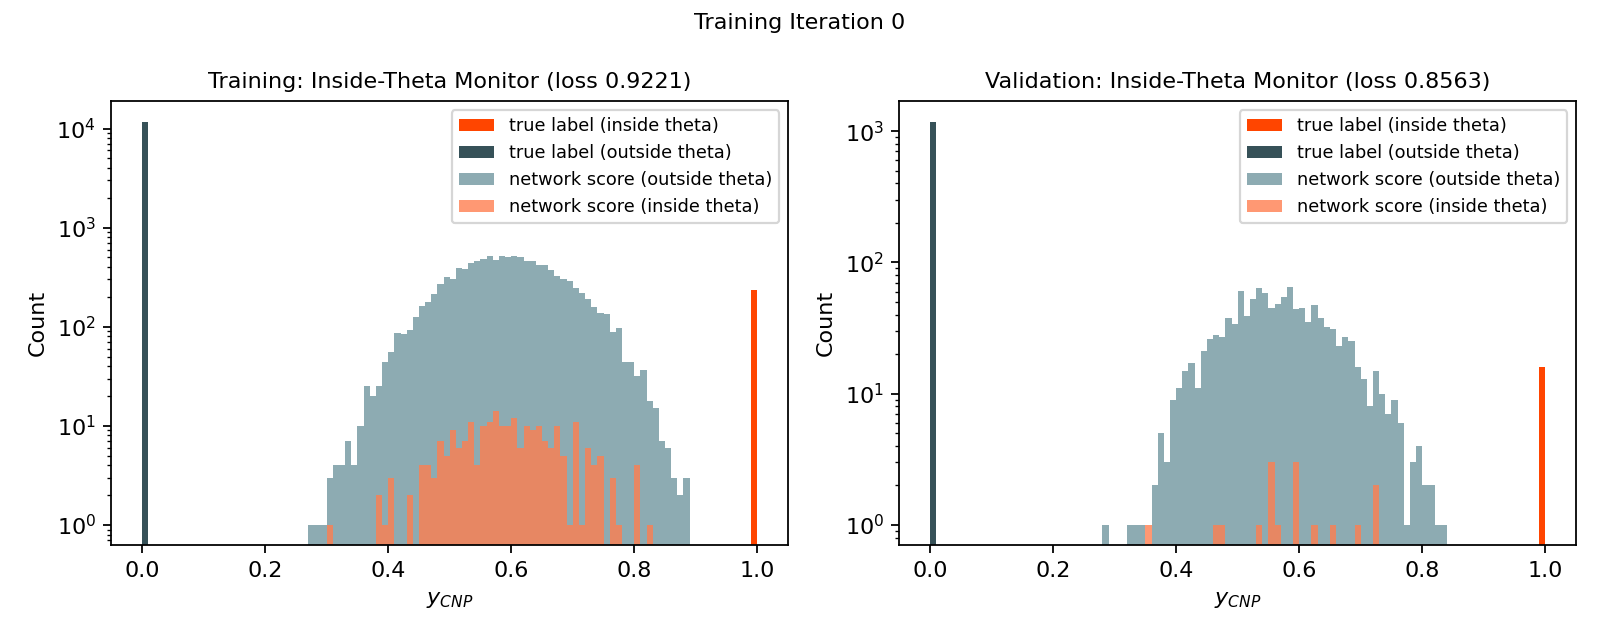

Epoch 1/15 | step=4999 | epoch_steps=5000 | train_bce=0.07665 | val_bce=0.03671
2026-05-19 11:11:49 Iteration: 1/5000, train BCE: 0.0808, val BCE: 0.0507


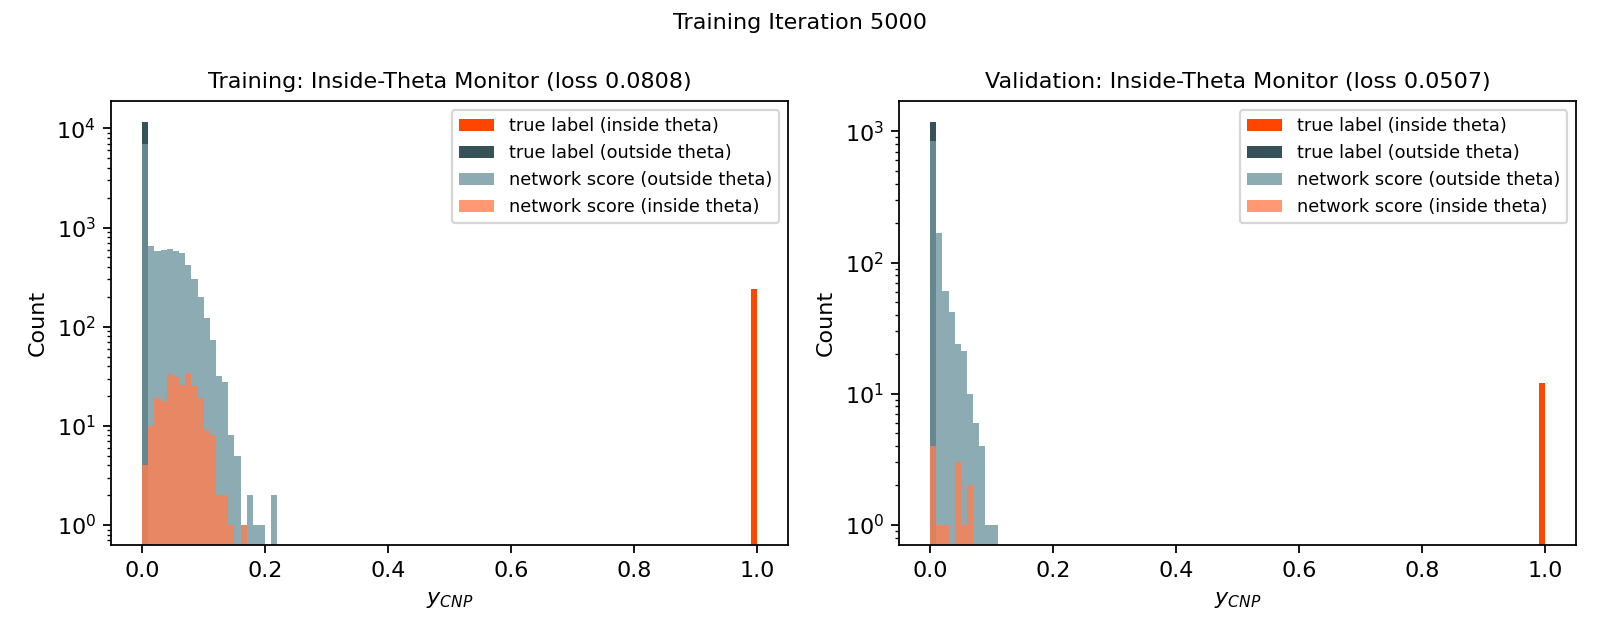

Epoch 2/15 | step=9999 | epoch_steps=5000 | train_bce=0.06045 | val_bce=0.04961
2026-05-19 11:12:10 Iteration: 2/10000, train BCE: 0.0917, val BCE: 0.0578


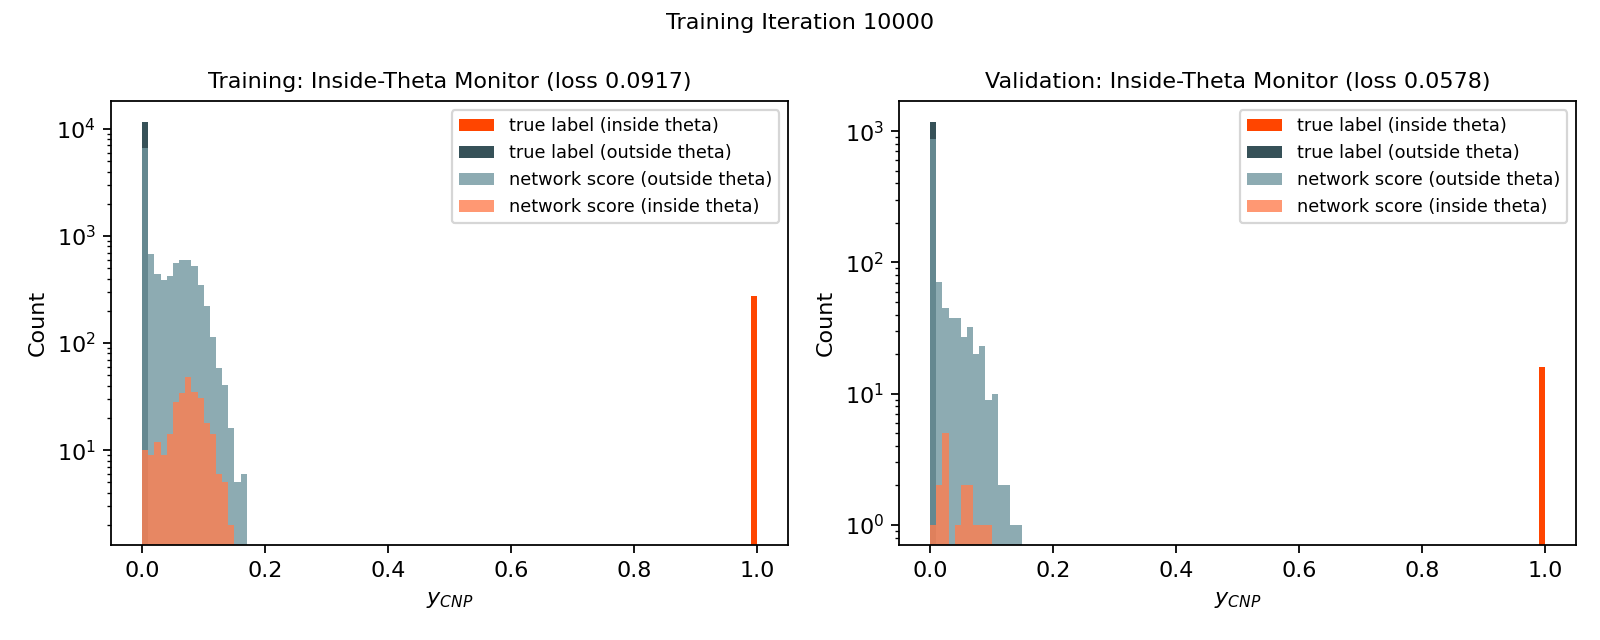

Epoch 3/15 | step=14999 | epoch_steps=5000 | train_bce=0.06368 | val_bce=0.07542
2026-05-19 11:12:30 Iteration: 3/15000, train BCE: 0.0630, val BCE: 0.0871


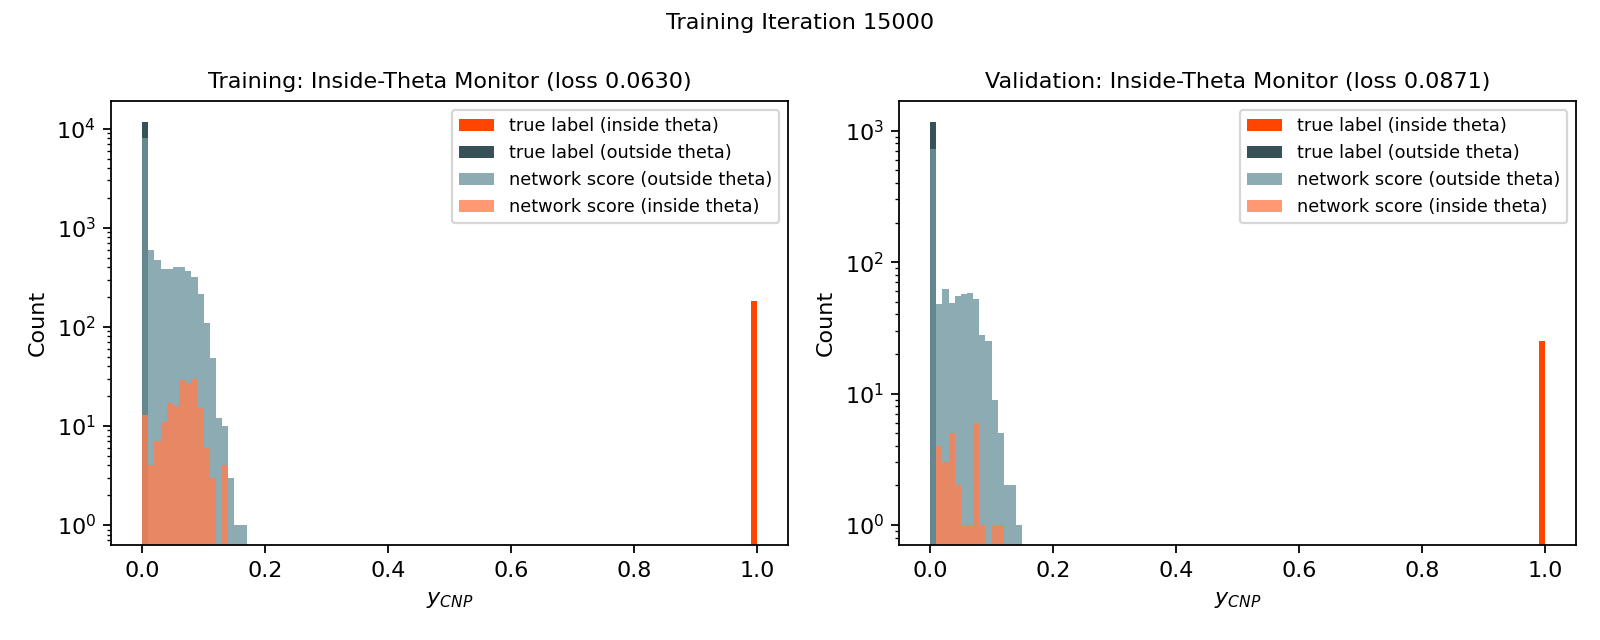

Epoch 4/15 | step=19999 | epoch_steps=5000 | train_bce=0.07626 | val_bce=0.05311
2026-05-19 11:12:52 Iteration: 4/20000, train BCE: 0.0834, val BCE: 0.0374


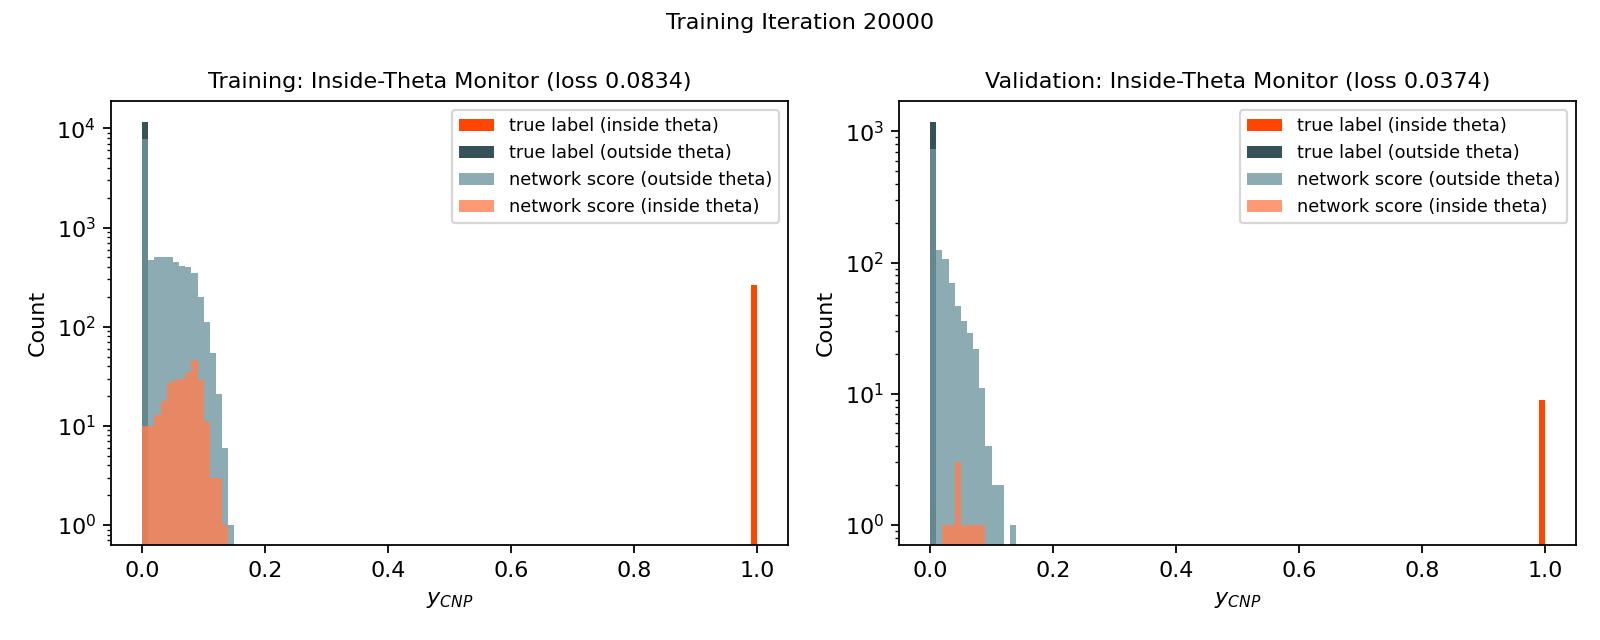

Epoch 5/15 | step=24999 | epoch_steps=5000 | train_bce=0.05913 | val_bce=0.06799
2026-05-19 11:13:12 Iteration: 5/25000, train BCE: 0.0636, val BCE: 0.0624


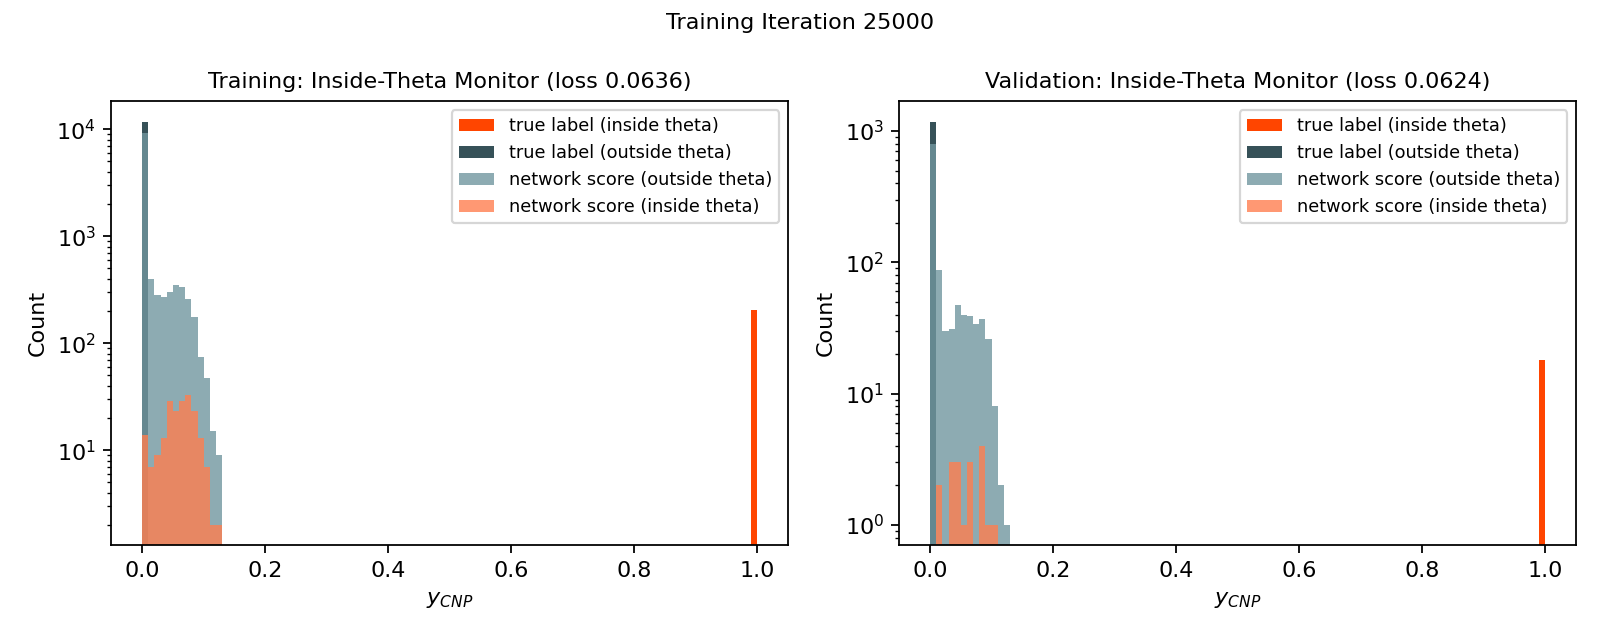

Epoch 6/15 | step=29999 | epoch_steps=5000 | train_bce=0.05218 | val_bce=0.10536
2026-05-19 11:13:33 Iteration: 6/30000, train BCE: 0.0724, val BCE: 0.0843


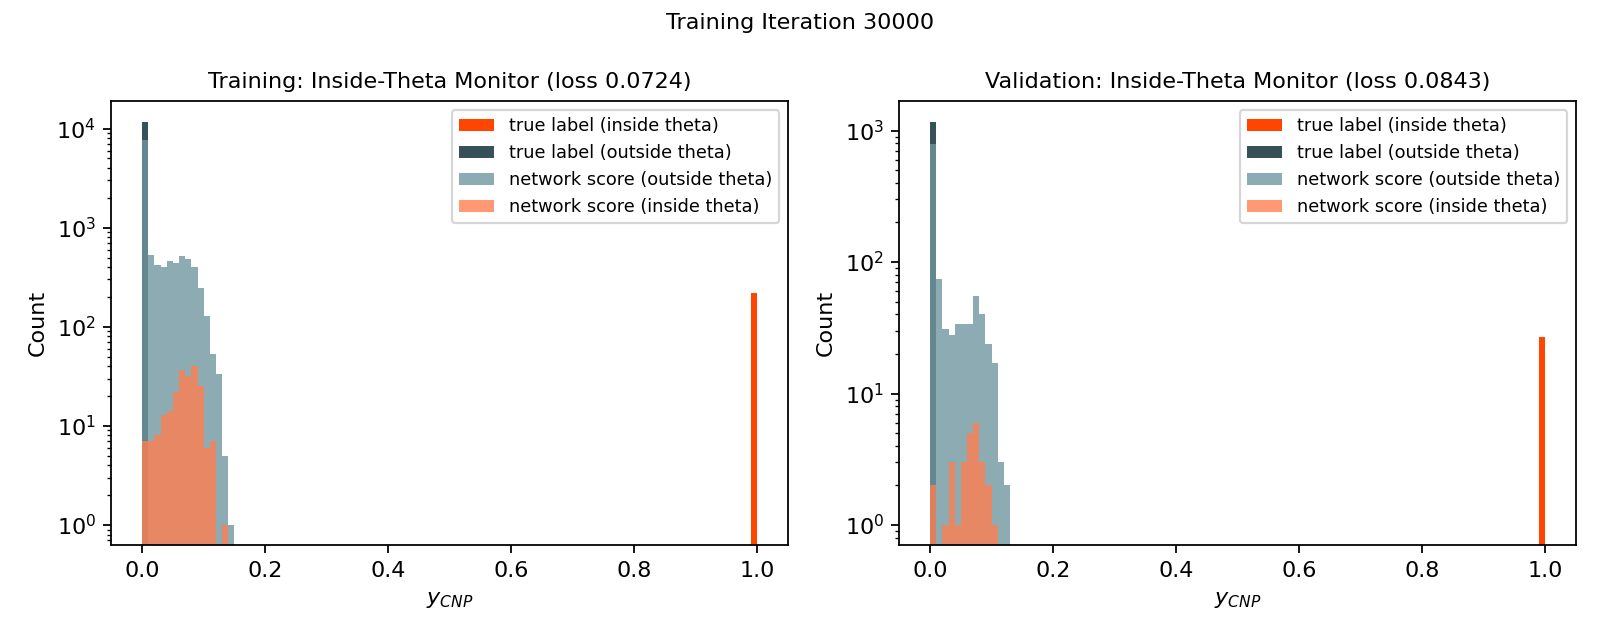

Epoch 7/15 | step=34999 | epoch_steps=5000 | train_bce=0.06665 | val_bce=0.02883
2026-05-19 11:13:54 Iteration: 7/35000, train BCE: 0.0553, val BCE: 0.0475


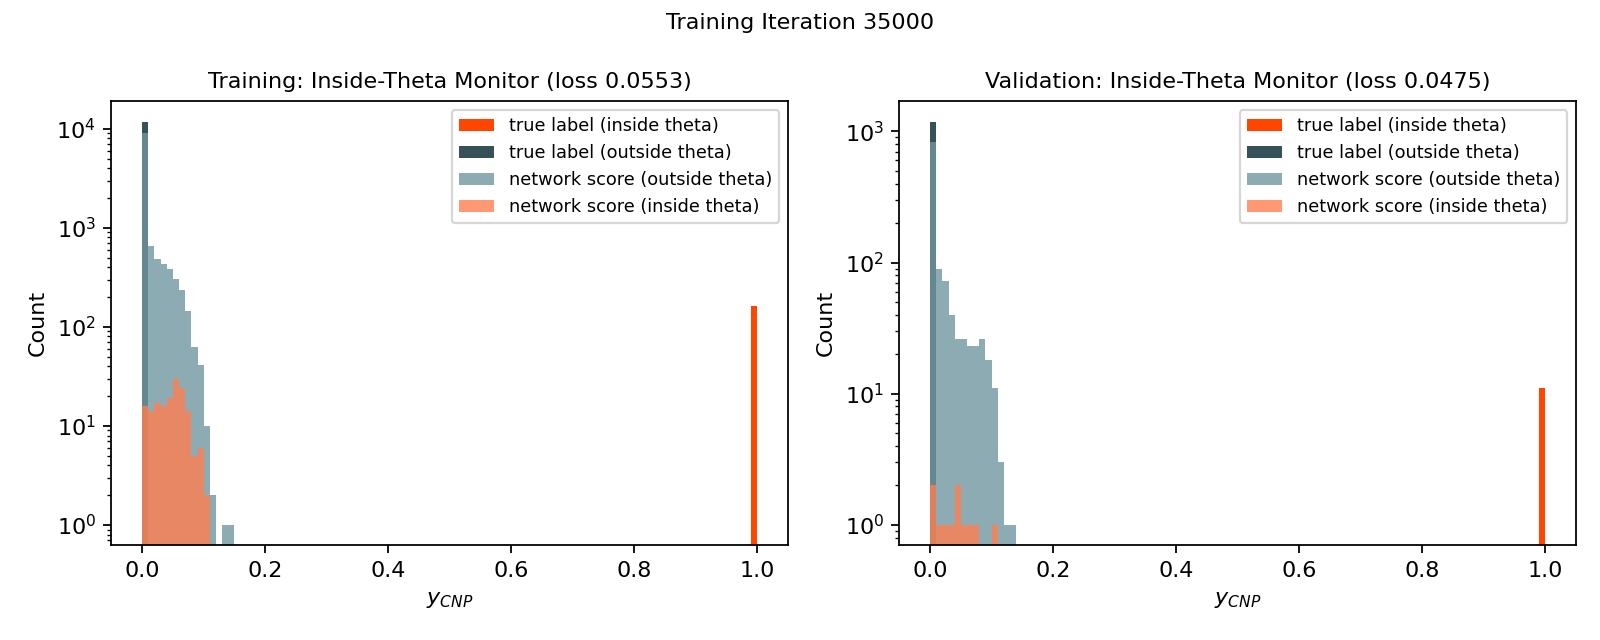

Epoch 8/15 | step=39999 | epoch_steps=5000 | train_bce=0.07976 | val_bce=0.08592
2026-05-19 11:14:14 Iteration: 8/40000, train BCE: 0.0765, val BCE: 0.0861


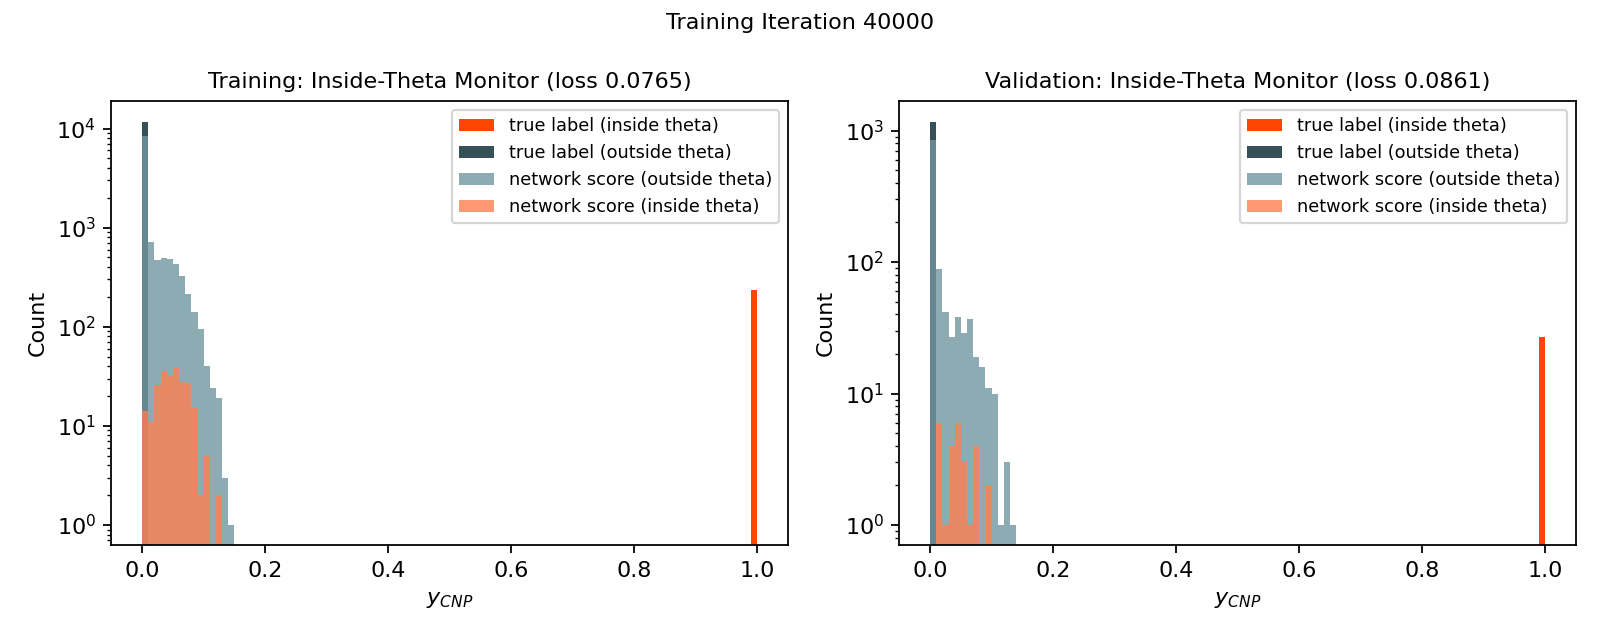

Epoch 9/15 | step=44999 | epoch_steps=5000 | train_bce=0.07073 | val_bce=0.06160
2026-05-19 11:14:35 Iteration: 9/45000, train BCE: 0.0760, val BCE: 0.0689


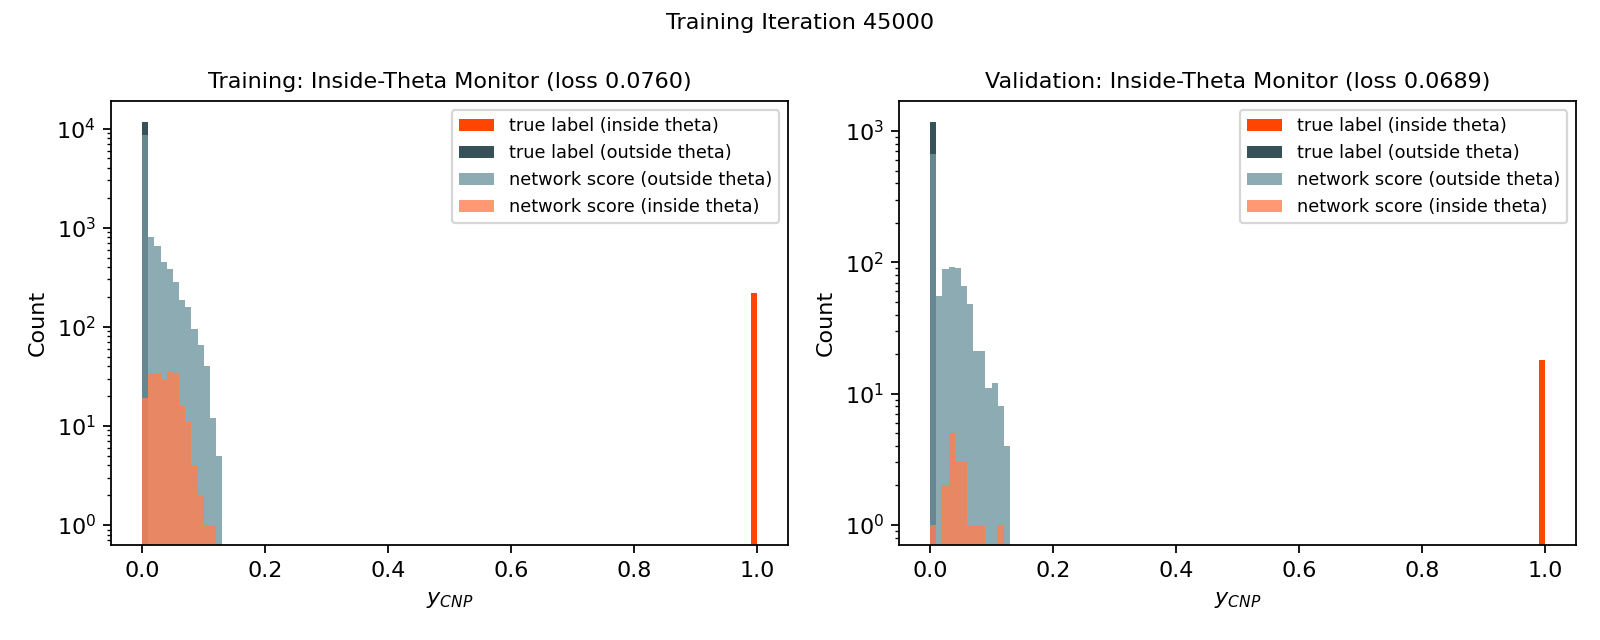

Epoch 10/15 | step=49999 | epoch_steps=5000 | train_bce=0.05579 | val_bce=0.01194
2026-05-19 11:14:55 Iteration: 10/50000, train BCE: 0.0713, val BCE: 0.0199


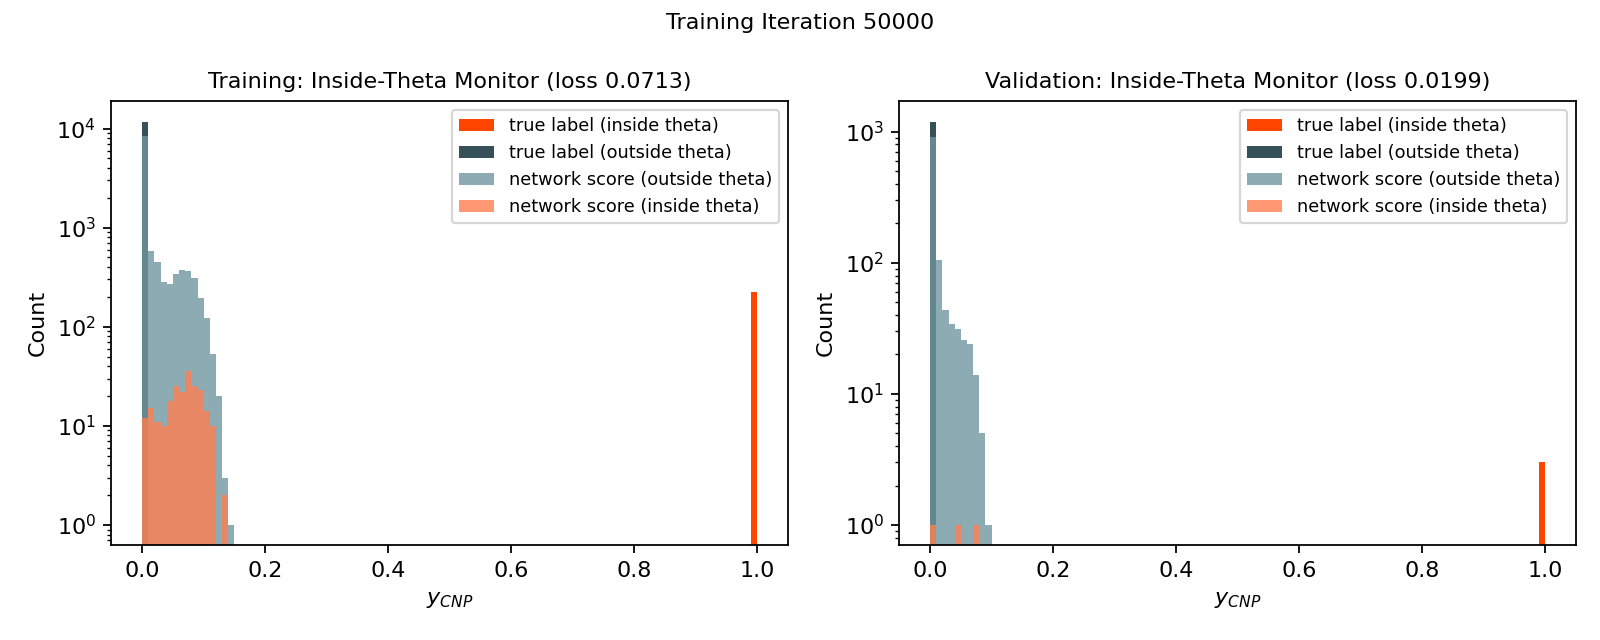

Epoch 11/15 | step=54999 | epoch_steps=5000 | train_bce=0.06665 | val_bce=0.03160
2026-05-19 11:15:17 Iteration: 11/55000, train BCE: 0.0686, val BCE: 0.0689


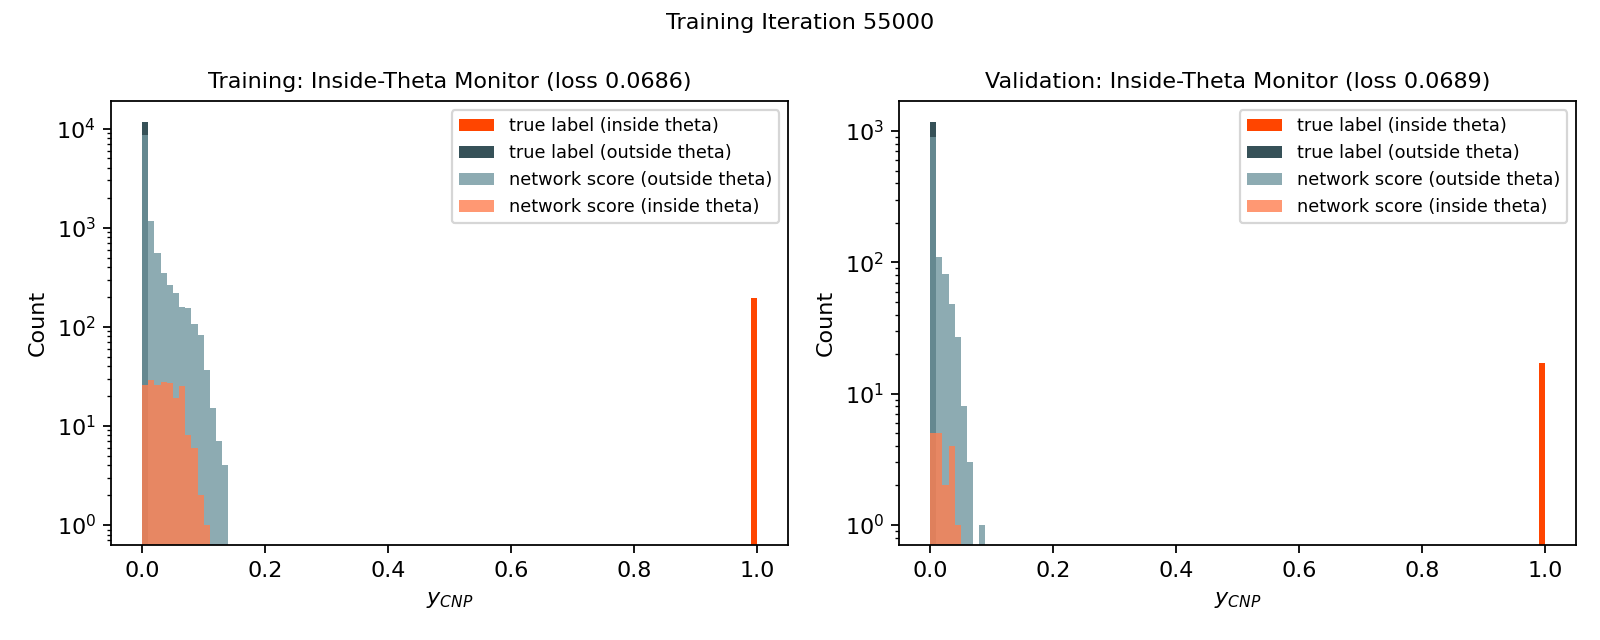

Epoch 12/15 | step=59999 | epoch_steps=5000 | train_bce=0.06594 | val_bce=0.10376
2026-05-19 11:15:37 Iteration: 12/60000, train BCE: 0.0586, val BCE: 0.0543


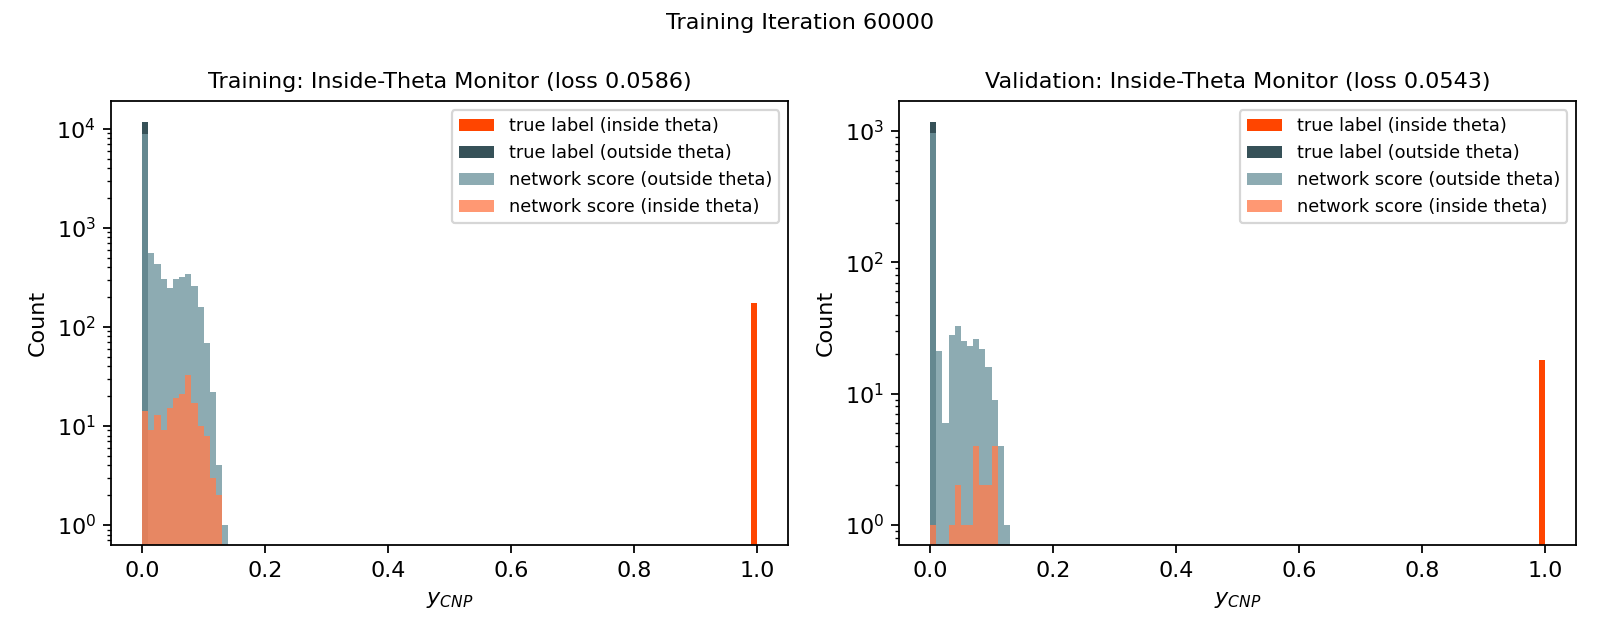

Epoch 13/15 | step=64999 | epoch_steps=5000 | train_bce=0.06084 | val_bce=0.07265
2026-05-19 11:15:58 Iteration: 13/65000, train BCE: 0.0566, val BCE: 0.0717


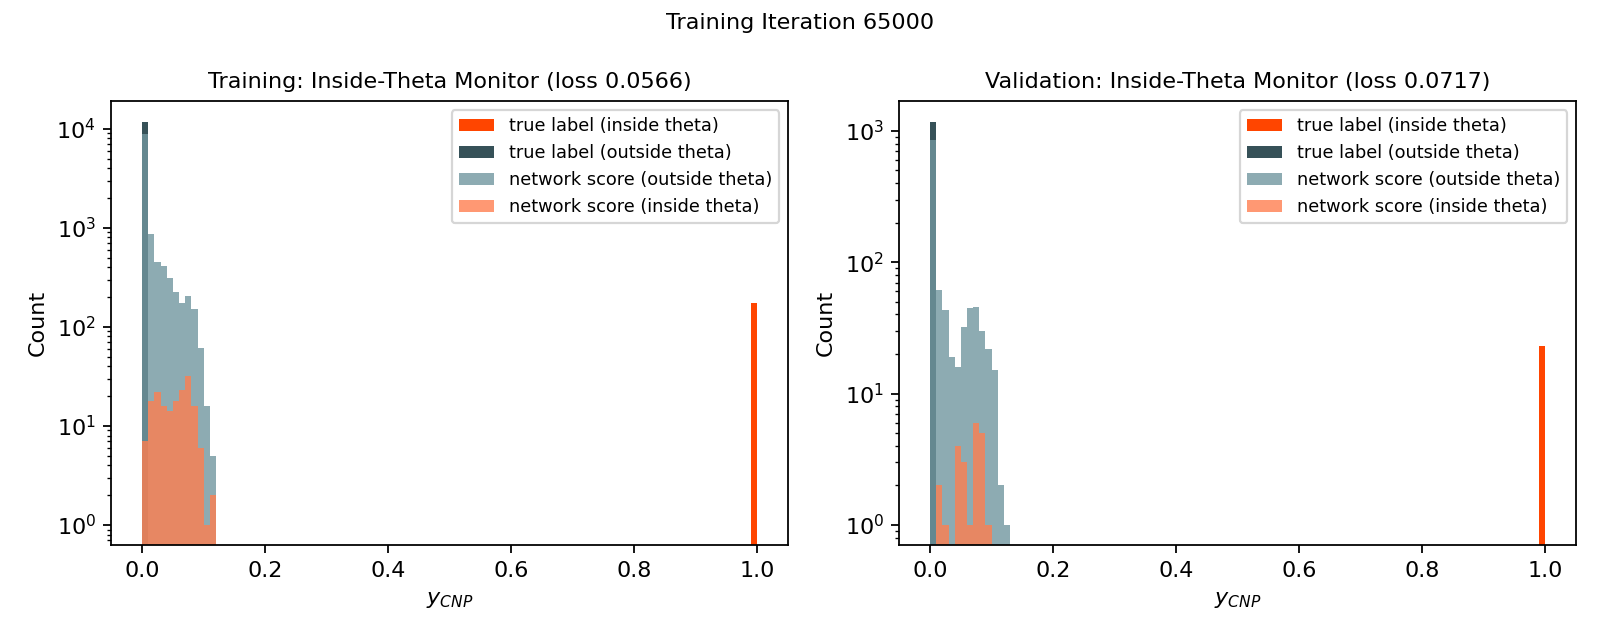

Epoch 14/15 | step=69999 | epoch_steps=5000 | train_bce=0.06207 | val_bce=0.06115
2026-05-19 11:16:19 Iteration: 14/70000, train BCE: 0.0733, val BCE: 0.0684


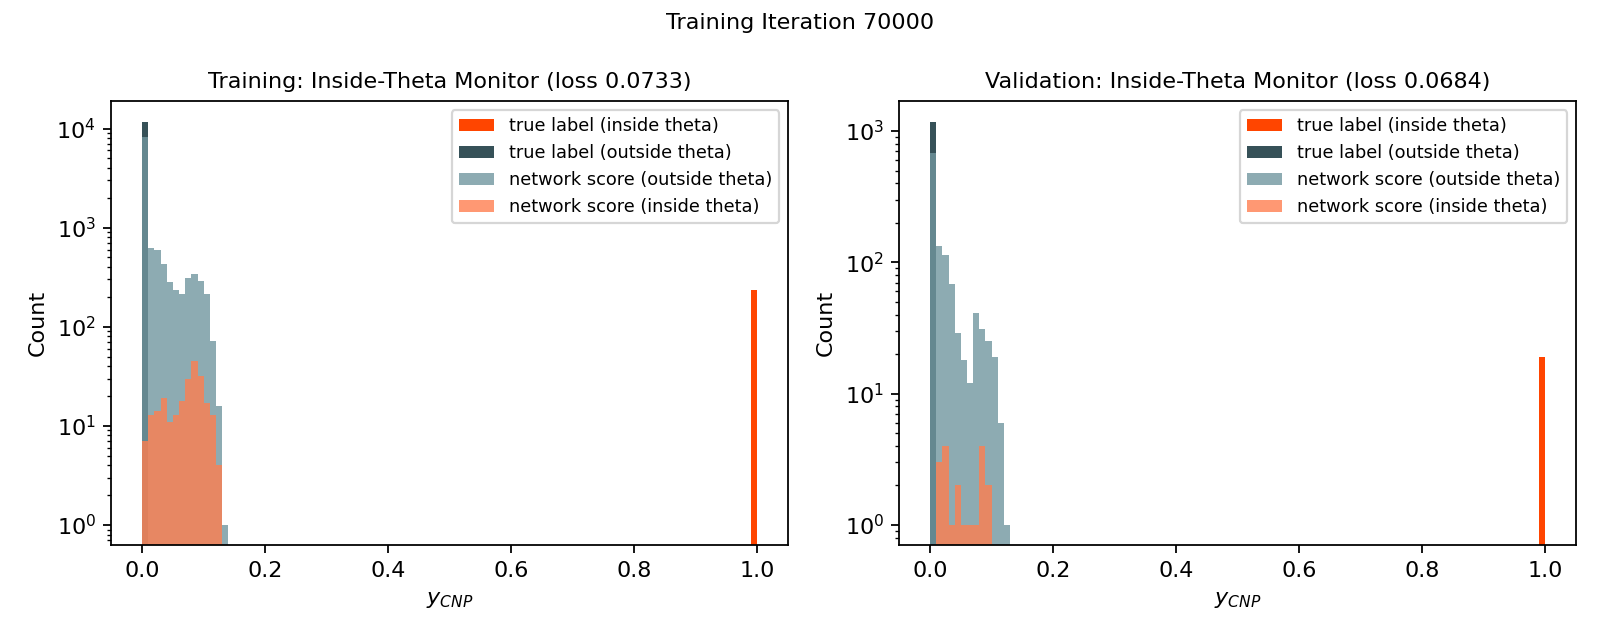

Epoch 15/15 | step=74999 | epoch_steps=5000 | train_bce=0.07782 | val_bce=0.07272


,artifact,path
0,model_path,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
1,history_csv,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
2,history_plot,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
3,sample_plot,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...


In [5]:
train_result = train_cnp(
    runtime,
    steps_per_epoch=STEPS_PER_EPOCH,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    repr_dim=REPR_DIM,
    hidden=HIDDEN,
    dropout=DROPOUT,
    monitor_every=MONITOR_EVERY,
    show_monitor_plots=True,
)

pd.DataFrame({
    "artifact": ["model_path", "history_csv", "history_plot", "sample_plot"],
    "path": [
        str(train_result.model_path),
        str(train_result.history_csv),
        str(train_result.history_plot),
        str(train_result.sample_plot),
    ],
})


## 5. Predict On Training LF/HF And Validation HF


In [6]:
train_prediction = predict_cnp(
    runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
)

validation_prediction = predict_cnp(
    validation_runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
)

pd.DataFrame({
    "artifact": [
        "train_csv",
        "train_heatmap",
        "train_error_heatmap",
        "validation_csv",
        "validation_heatmap",
        "validation_error_heatmap",
    ],
    "path": [
        str(train_prediction.csv_path),
        str(train_prediction.heatmap_path),
        str(train_prediction.error_heatmap_path),
        str(validation_prediction.csv_path),
        str(validation_prediction.heatmap_path),
        str(validation_prediction.error_heatmap_path),
    ],
})


/home/liuser/miniconda3/lib/python3.12/site-packages/scipy/interpolate/_ndgriddata.py:323: GradientEstimationWarning: Gradient estimation did not converge, the results may be inaccurate
  ip = CloughTocher2DInterpolator(points, values, fill_value=fill_value,


Prediction summary: rows=64, MAE=0.006229, RMSE=0.016644


/home/liuser/miniconda3/lib/python3.12/site-packages/scipy/interpolate/_ndgriddata.py:323: GradientEstimationWarning: Gradient estimation did not converge, the results may be inaccurate
  ip = CloughTocher2DInterpolator(points, values, fill_value=fill_value,


Prediction summary: rows=19, MAE=0.005198, RMSE=0.020329


,artifact,path
0,train_csv,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
1,train_heatmap,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
2,train_error_heatmap,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
3,validation_csv,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
4,validation_heatmap,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
5,validation_error_heatmap,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...


## 6. Inspect CNP Outputs


,iteration,fidelity,n_samples,R_shell,Z_shell,y_cnp,y_cnp_err,y_raw,log_prop,bce,source_file
0,0.0,0.0,20097.0,912.330322,1216.440430,0.000009,1.193714,0.0000,-0.000009,0.000009,lf_shell018_R912p330_Z1216p440.h5
1,0.0,0.0,20097.0,928.921753,1238.562378,0.000012,1.171988,0.0000,-0.000012,0.000012,lf_shell019_R928p922_Z1238p562.h5
2,0.0,0.0,20097.0,944.940796,1259.921021,0.000014,1.158920,0.0000,-0.000014,0.000014,lf_shell020_R944p941_Z1259p921.h5
3,0.0,0.0,20097.0,960.434387,1280.579224,0.000020,1.137815,0.0000,-0.000020,0.000020,lf_shell021_R960p434_Z1280p579.h5
4,0.0,0.0,20097.0,975.443604,1300.591431,0.000023,1.127377,0.0001,-0.000935,0.000935,lf_shell022_R975p444_Z1300p591.h5


,iteration,fidelity,n_samples,R_shell,Z_shell,y_cnp,y_cnp_err,y_raw,log_prop,bce,source_file
0,0.0,1.0,101440.0,839.016724,1118.688965,0.000003,1.283365,0.000010,-0.000106,0.000106,hf_shell014_R839p017_Z1118p689.h5
1,0.0,1.0,101440.0,877.205322,1169.607056,0.000005,1.236508,0.000000,-0.000005,0.000005,hf_shell016_R877p205_Z1169p607.h5
2,0.0,1.0,101440.0,895.112366,1193.483154,0.000007,1.212731,0.000010,-0.000141,0.000141,hf_shell017_R895p112_Z1193p483.h5
3,0.0,1.0,101440.0,990.004578,1320.006104,0.000030,1.110365,0.000030,-0.000331,0.000331,hf_shell023_R990p005_Z1320p006.h5
4,0.0,1.0,101440.0,1044.357544,1392.476685,0.000068,1.057006,0.000079,-0.000807,0.000807,hf_shell027_R1044p357_Z1392p477.h5


/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_training_curve_15epochs.png


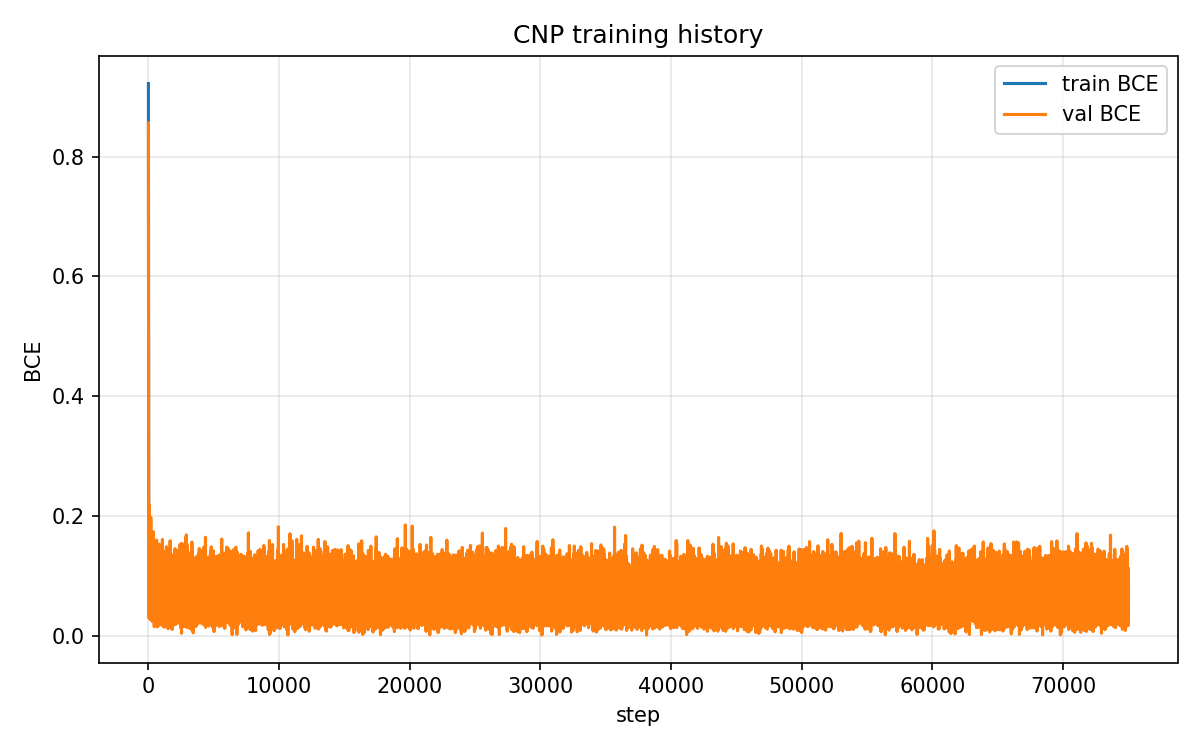

/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_sample_predictions_15epochs.png


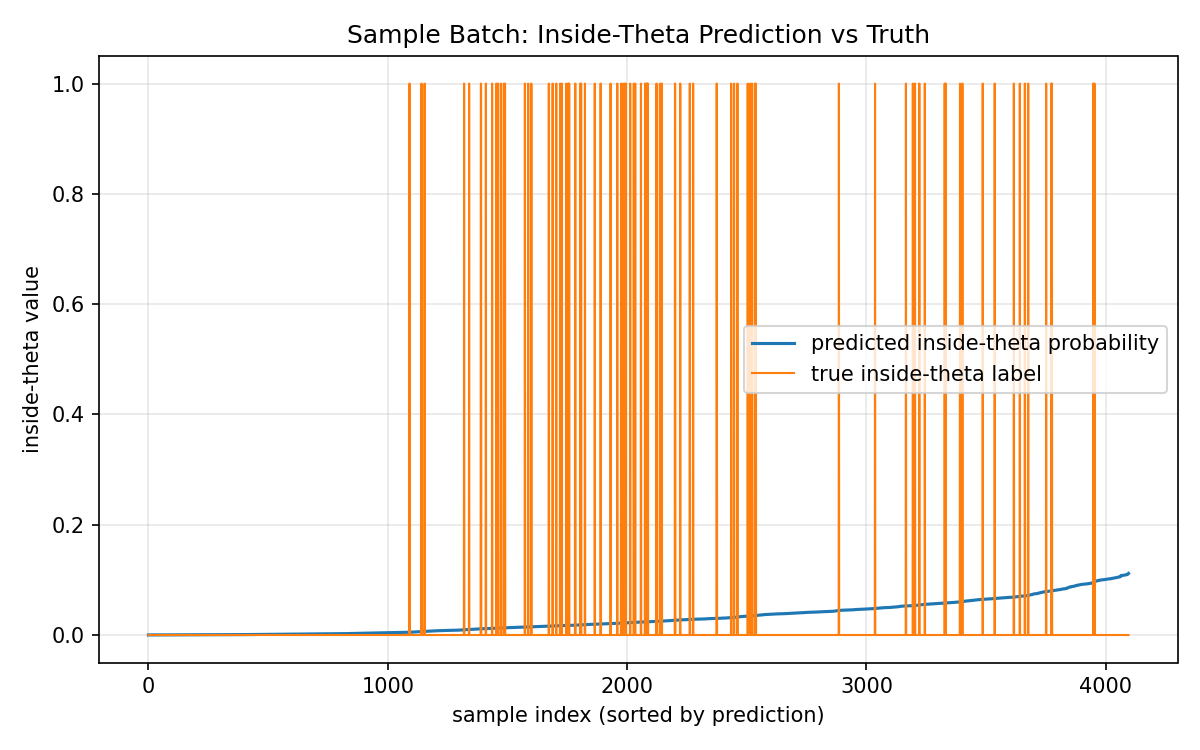

/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_15epochs_heatmaps.png


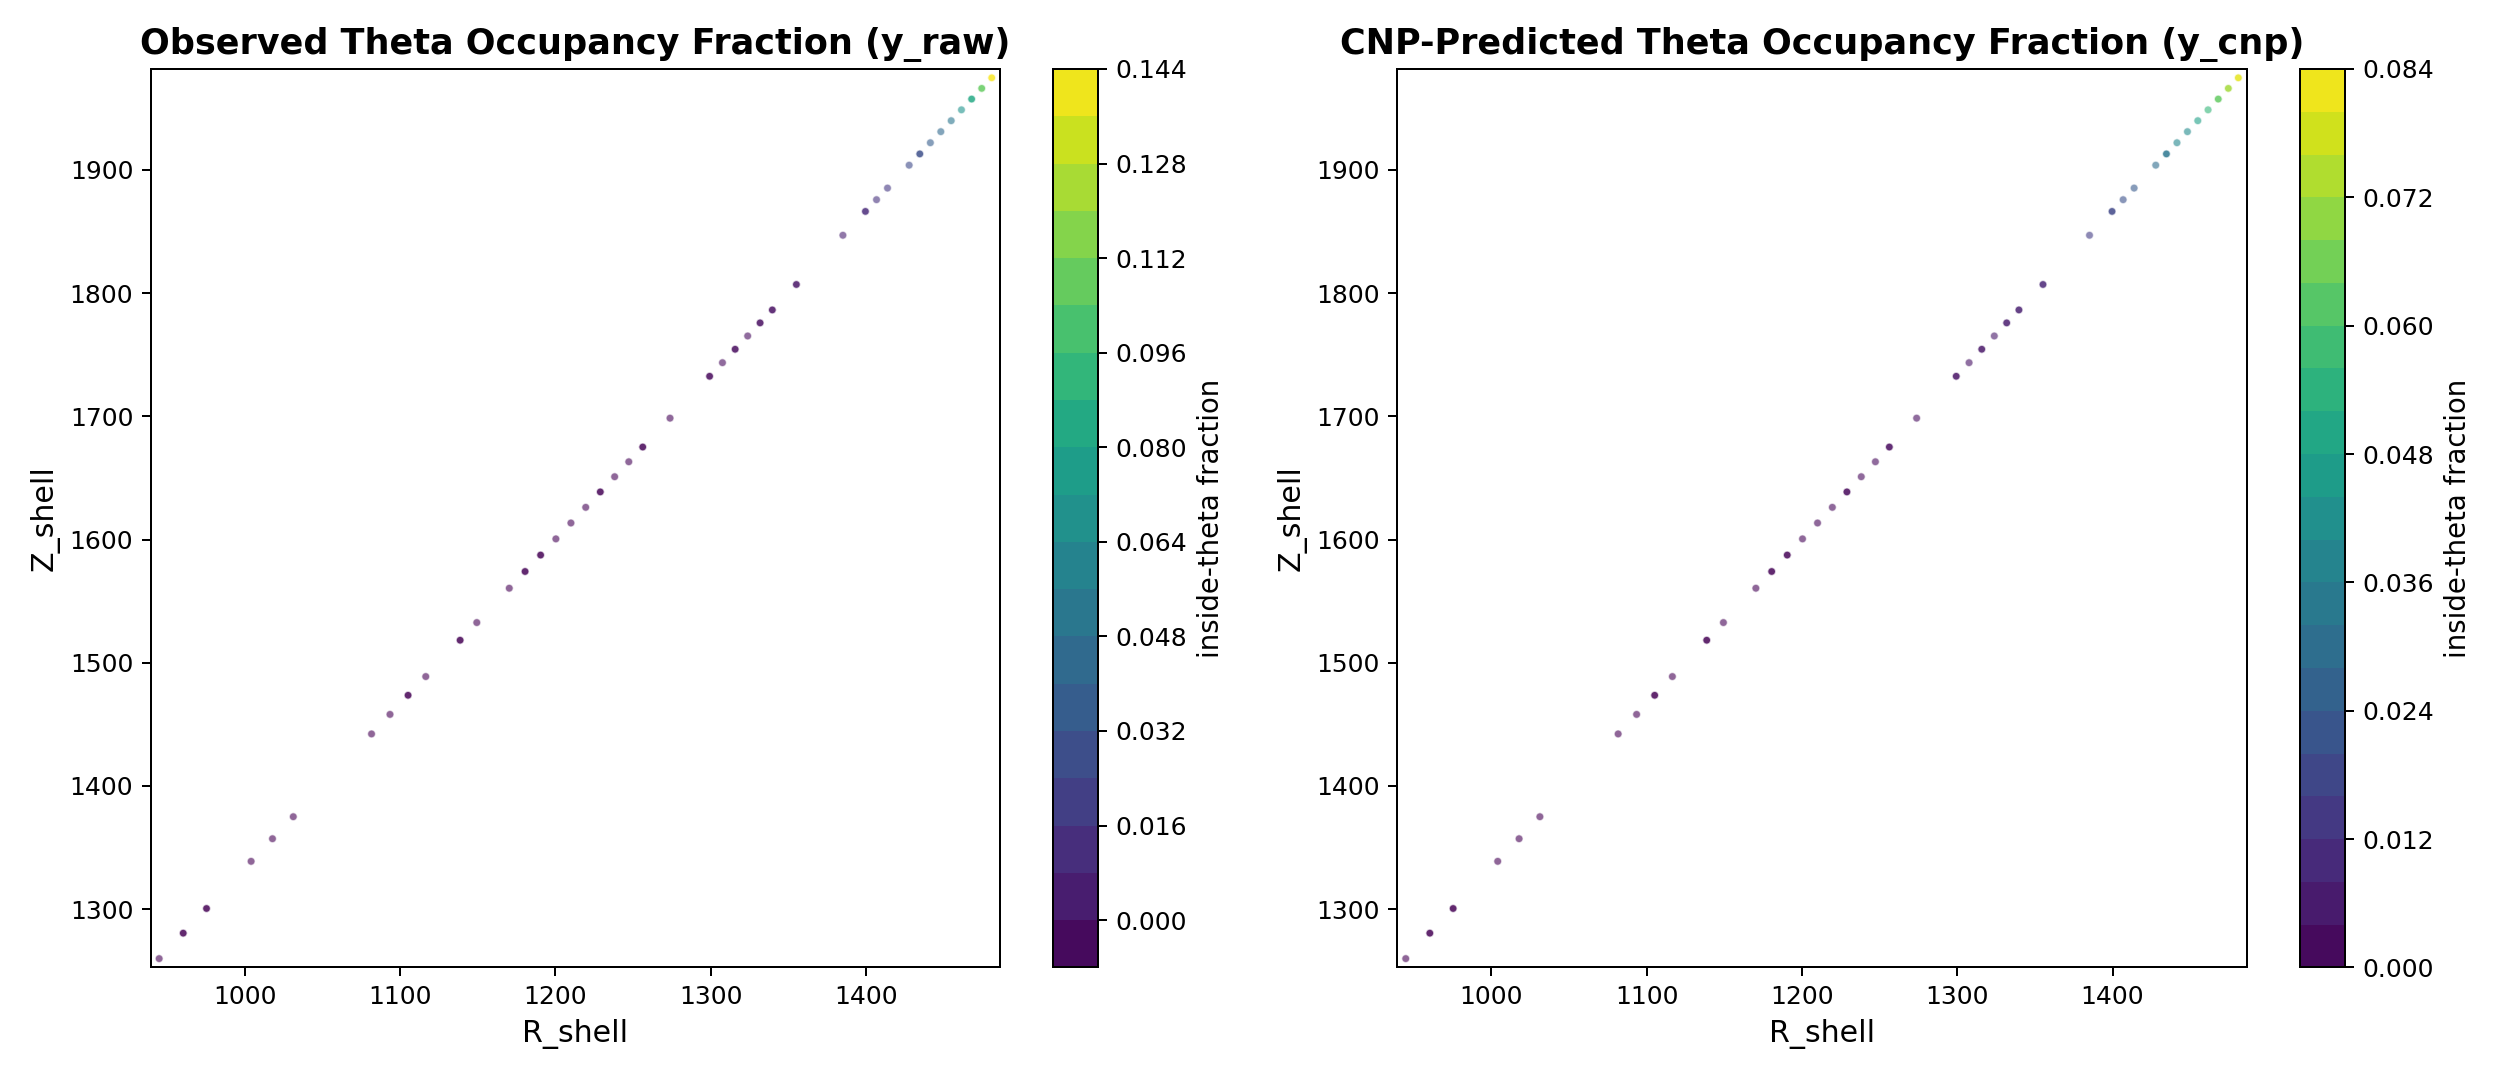

/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_15epochs_error_heatmap.png


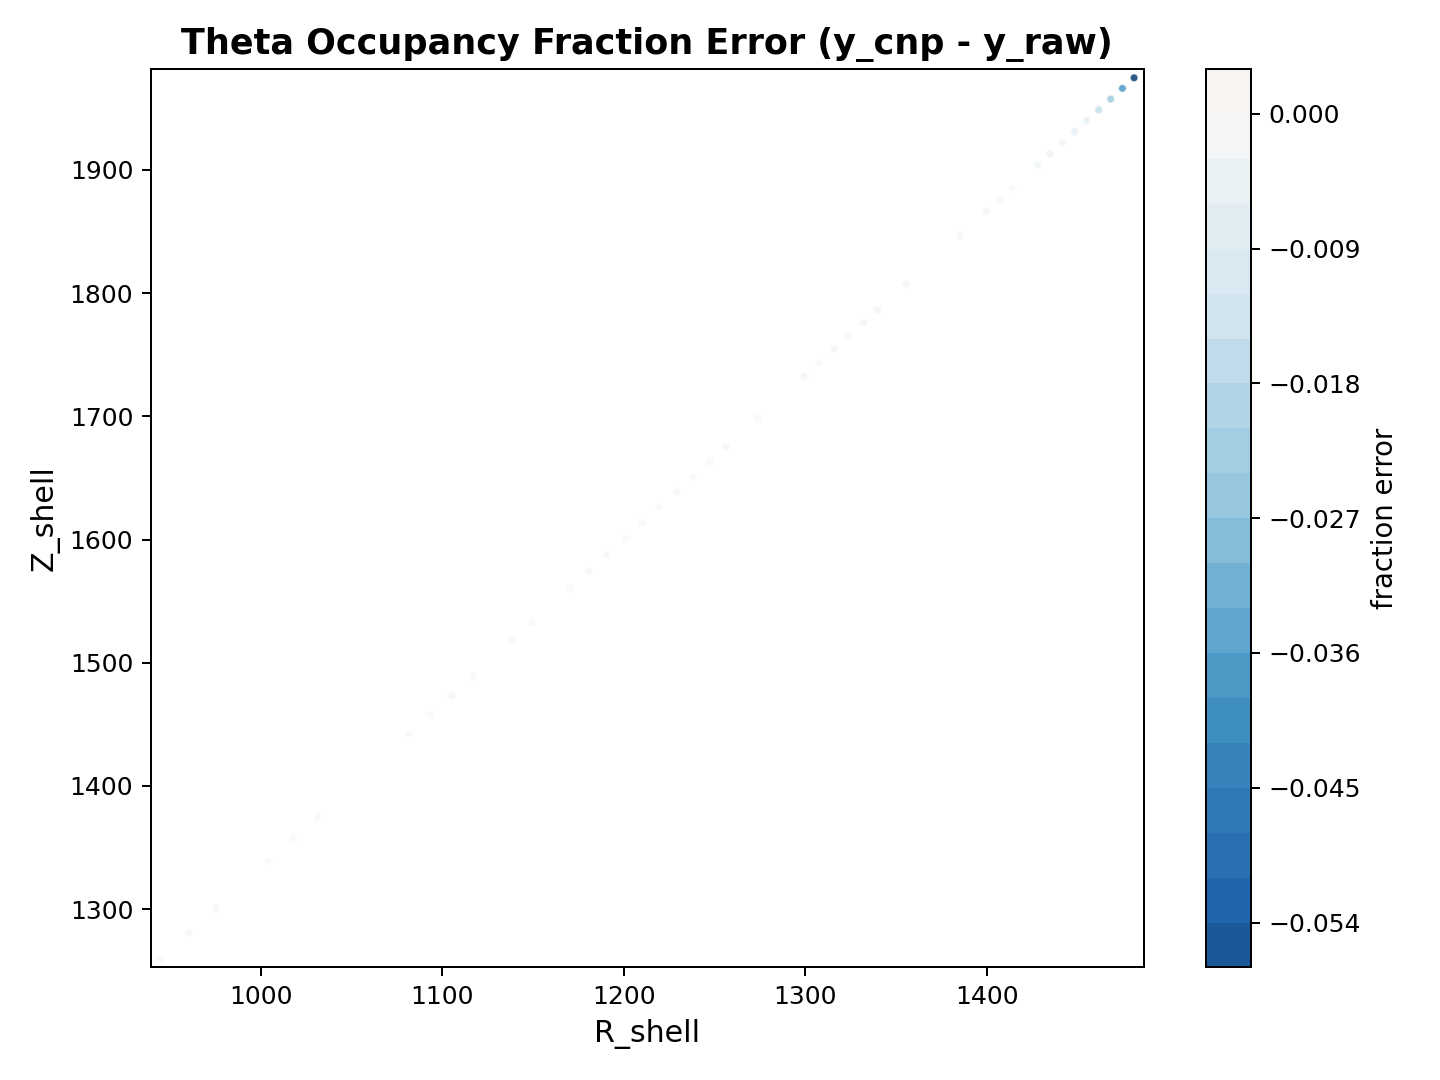

/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_validation_15epochs_heatmaps.png


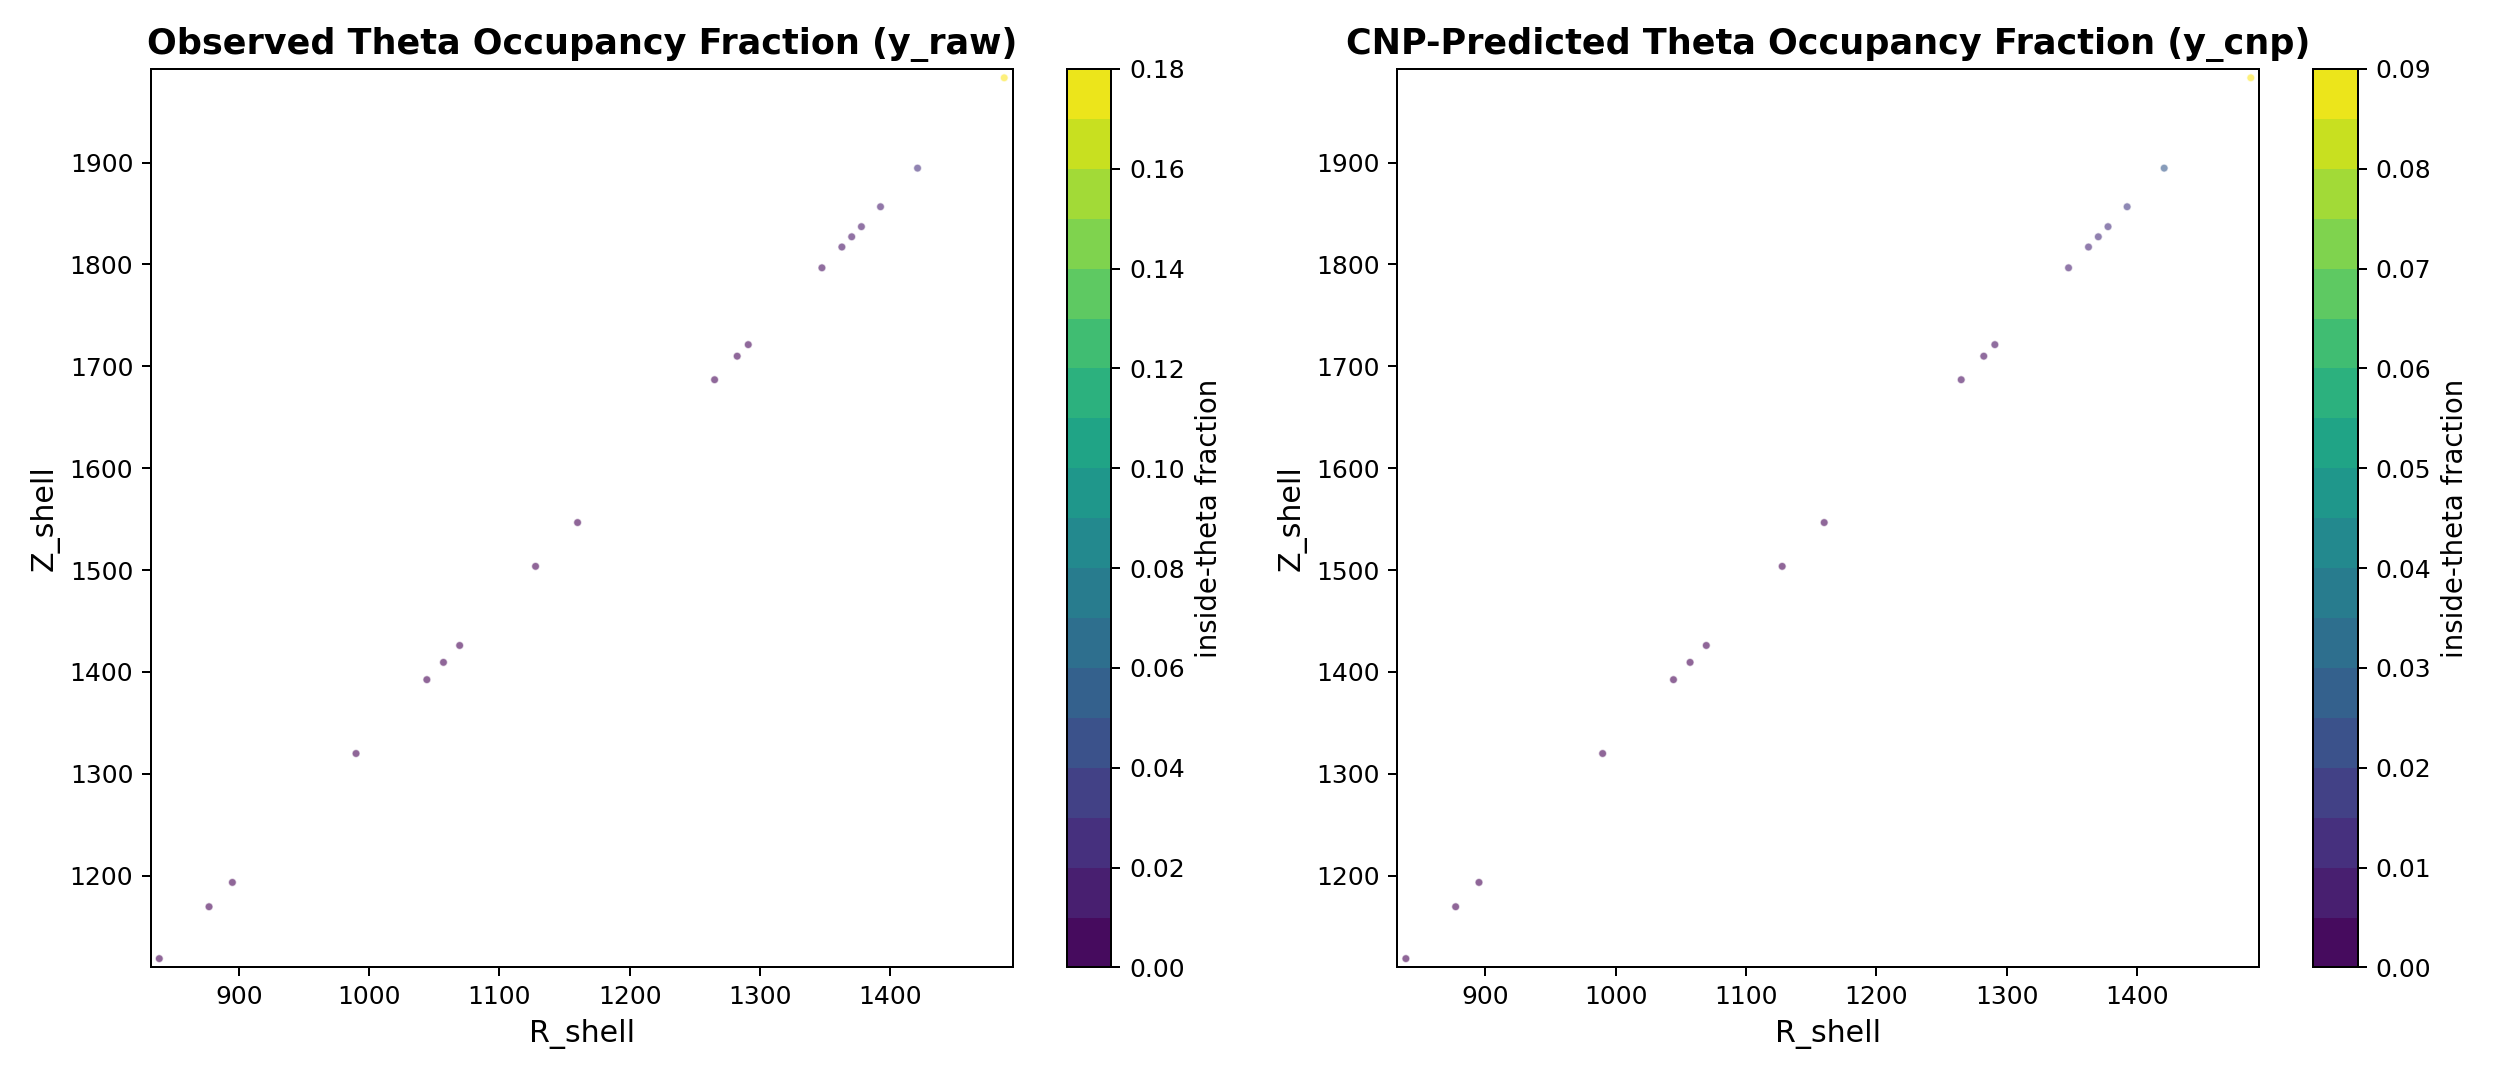

/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_validation_15epochs_error_heatmap.png


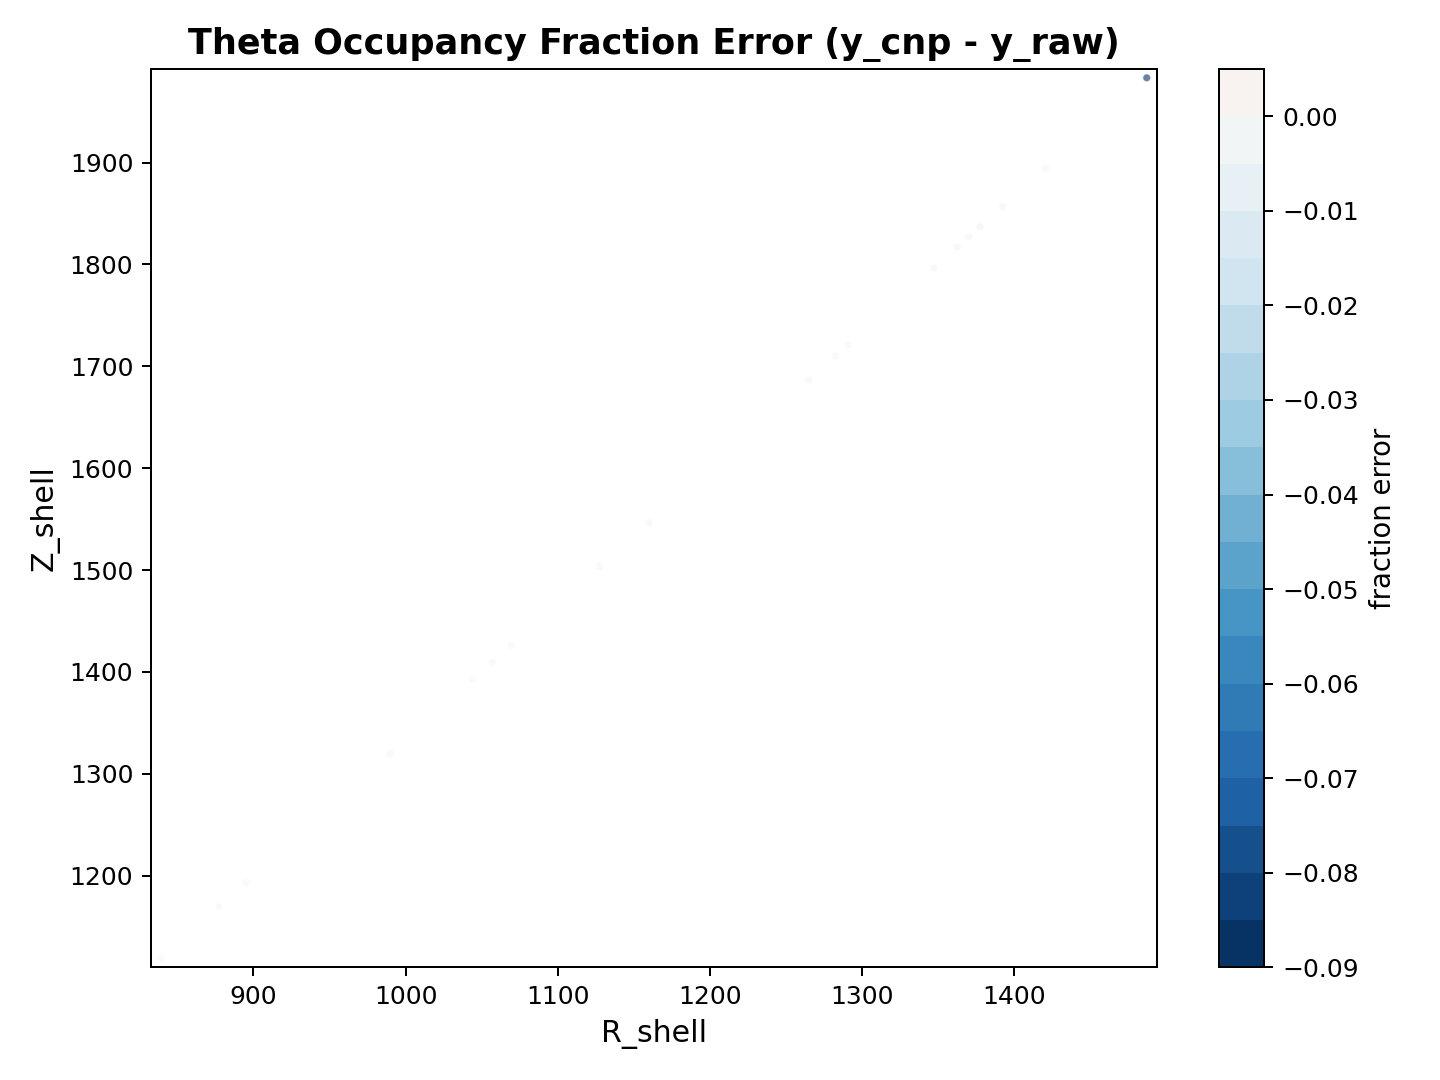

In [7]:
train_df = pd.read_csv(CNP_TRAIN_CSV)
validation_df = pd.read_csv(CNP_VALIDATION_CSV)

display(train_df.head())
display(validation_df.head())

for path in [
    train_result.history_plot,
    train_result.sample_plot,
    train_prediction.heatmap_path,
    train_prediction.error_heatmap_path,
    validation_prediction.heatmap_path,
    validation_prediction.error_heatmap_path,
]:
    print(path)
    if Path(path).exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass


## 7. Fit The MF-GP Transform Suite


In [8]:
mfgp_results = run_mfgp_transform_suite(
    config_path=CONFIG_PATH,
    cnp_csv=CNP_TRAIN_CSV,
    validation_csv=CNP_VALIDATION_CSV,
    transforms=TARGET_TRANSFORMS,
    iteration=0,
    grid_points_per_axis=GRID_POINTS,
    random_state=RANDOM_STATE,
    predict_chunk_size=CHUNK_SIZE,
    verbose=True,
)

metrics_rows = []
for transform, result in mfgp_results.items():
    metrics_path = getattr(result, "metrics_json", None)
    if metrics_path and Path(metrics_path).exists():
        payload = json.loads(Path(metrics_path).read_text())
        metrics_rows.append({"transform": transform, **payload})
pd.DataFrame(metrics_rows) if metrics_rows else pd.DataFrame()



=== Running MF-GP target transform: linear ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_15epochs.csv
[stage] Loading LF/HF training rows...
[data] n_lf=46 n_hf=18 x_dim=2
[data] target_transform=linear use_log_lf=False use_log_hf=False eps=4.563e-06
[data] lf_cnp_noise=9.034e-01 hf_sim_noise=4.160e-02 alpha_lf=9.034e-01 alpha_hf=4.160e-10
[fit] Training LF GP...
[fit] Estimated rho=1.779648
[fit] Training HF discrepancy GP...
[fit] GP training complete.
[stage] Predicting on HF observations...
[progress] HF predict 18/18
[stage] Predicting on grid (3600 points)...
[progress] Grid predict 3600/3600
[stage] Loading validation CSV for extra plots: /home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_equal_volume_shell_v1_minibatch_output_validation_15epochs.csv
[done] Generated theta-group uncertainty plots: 38
[done] MFGP complete | version=xlzd_equal_volume_shell_v1_minibatch | n_l

,transform,rmse_hf,mae_hf,r2_hf,n_lf,n_hf,rho,target_transform,target_transform_eps
0,linear,0.007288,0.003682,0.969306,46,18,1.779648,linear,0.000005
1,log_hf,0.020634,0.014682,0.999675,46,18,-31.779401,log_hf,0.000005
2,log_lf,0.004926,0.002132,0.985977,46,18,-0.008188,log_lf,0.000005
3,log_both,0.032641,0.025840,0.999188,46,18,0.948137,log_both,0.000005


## 8. Display MF-GP Plots


=== Normal MF-GP ===
4-fold MF-GP mean/std: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_mean_std_iter0.png


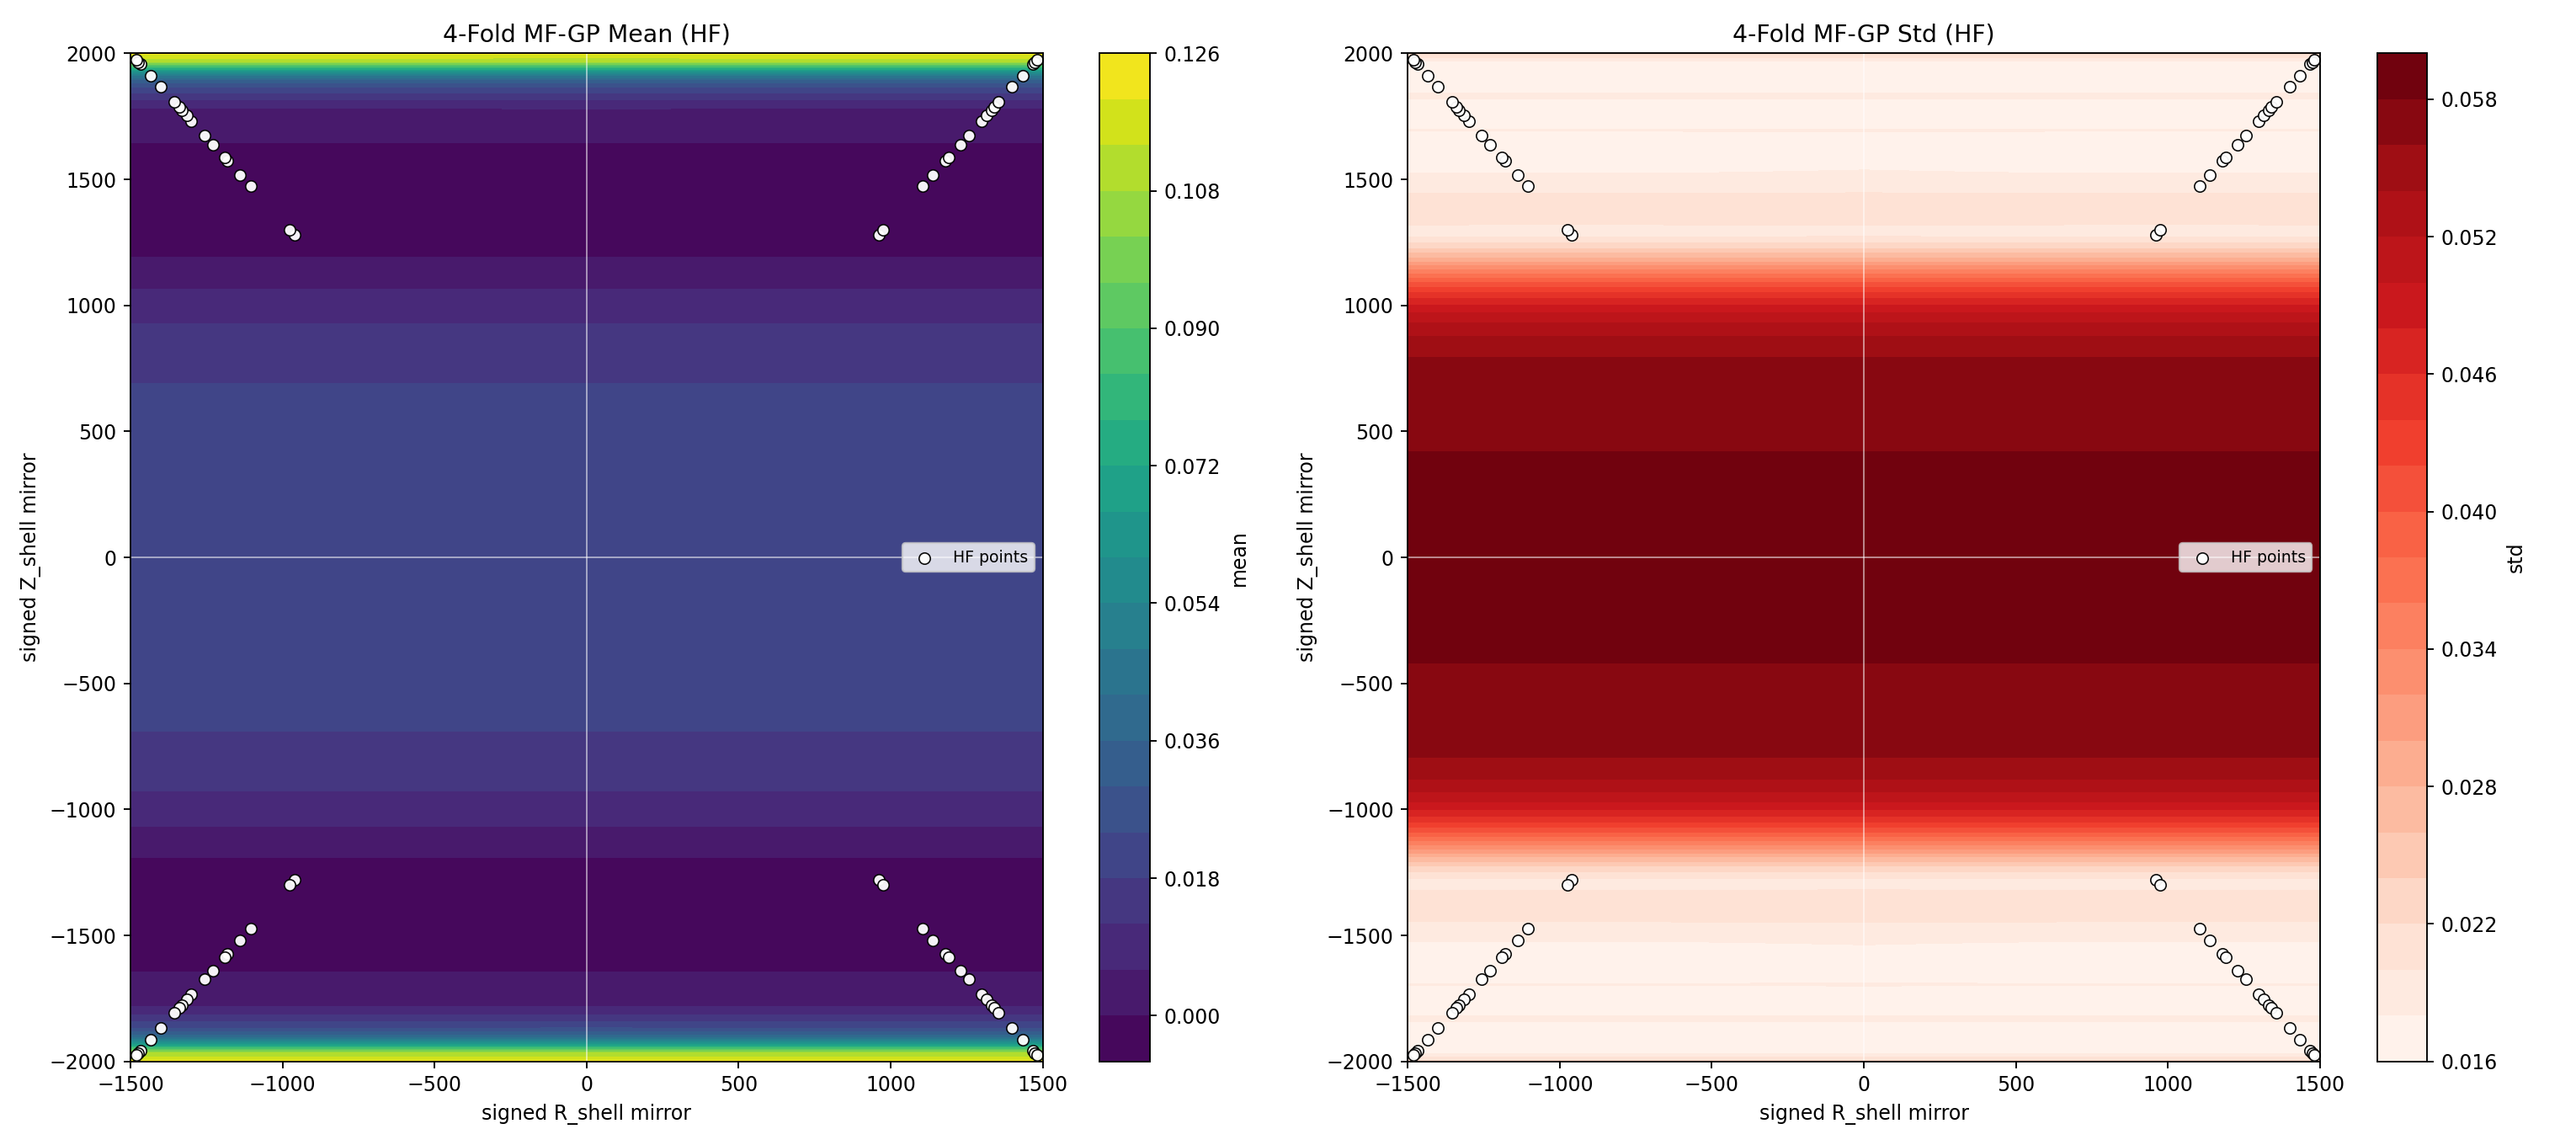

Interactive 3D mean/std HTML: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_across_thetas_linear_iter0.png


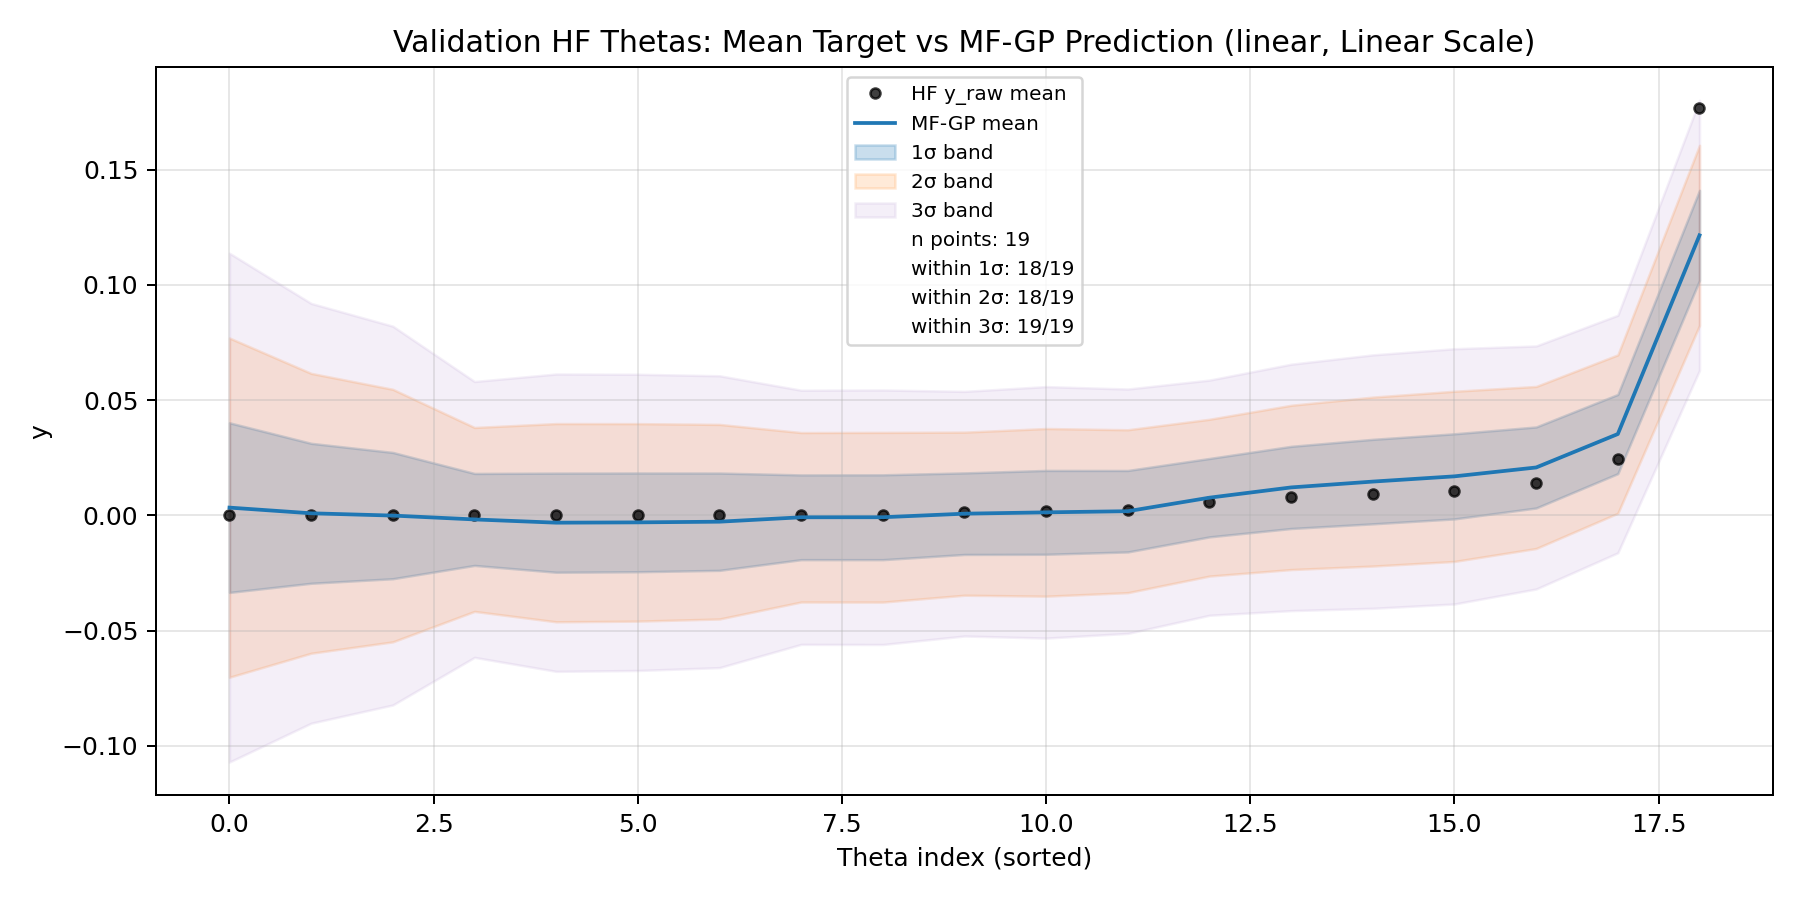

Validation 3-sigma: log10(y) with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_across_thetas_log_linear_sigma_iter0.png


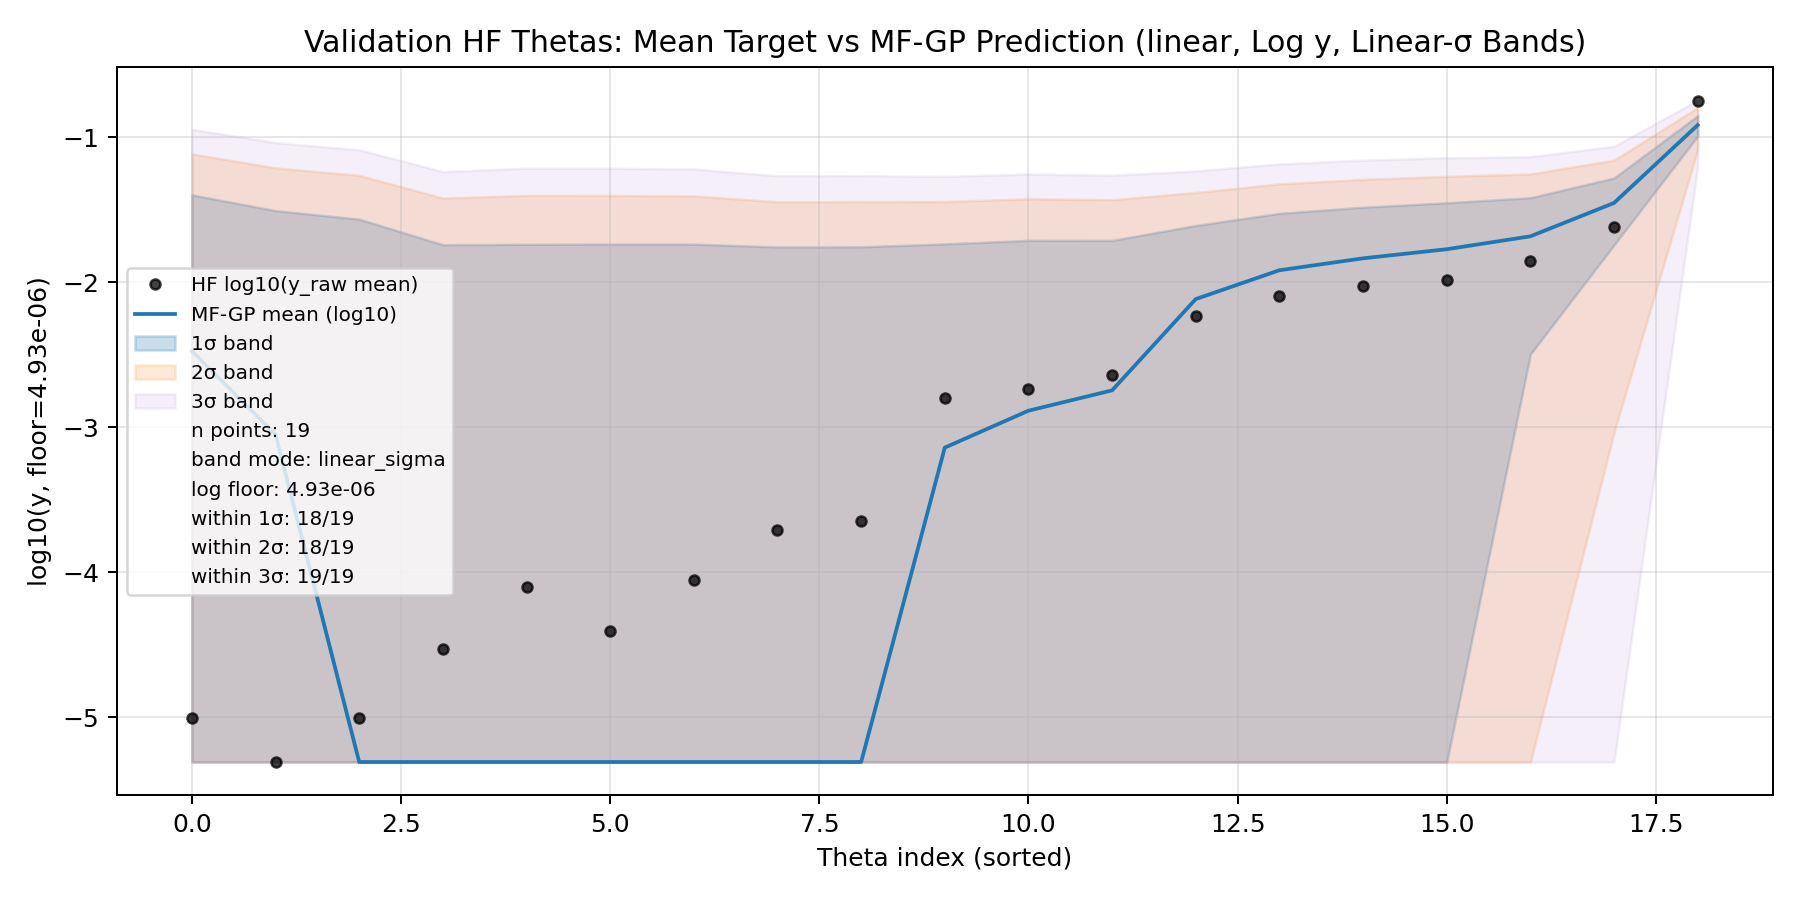

Validation parity: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_linear_validation_parity_linear_iter0.png


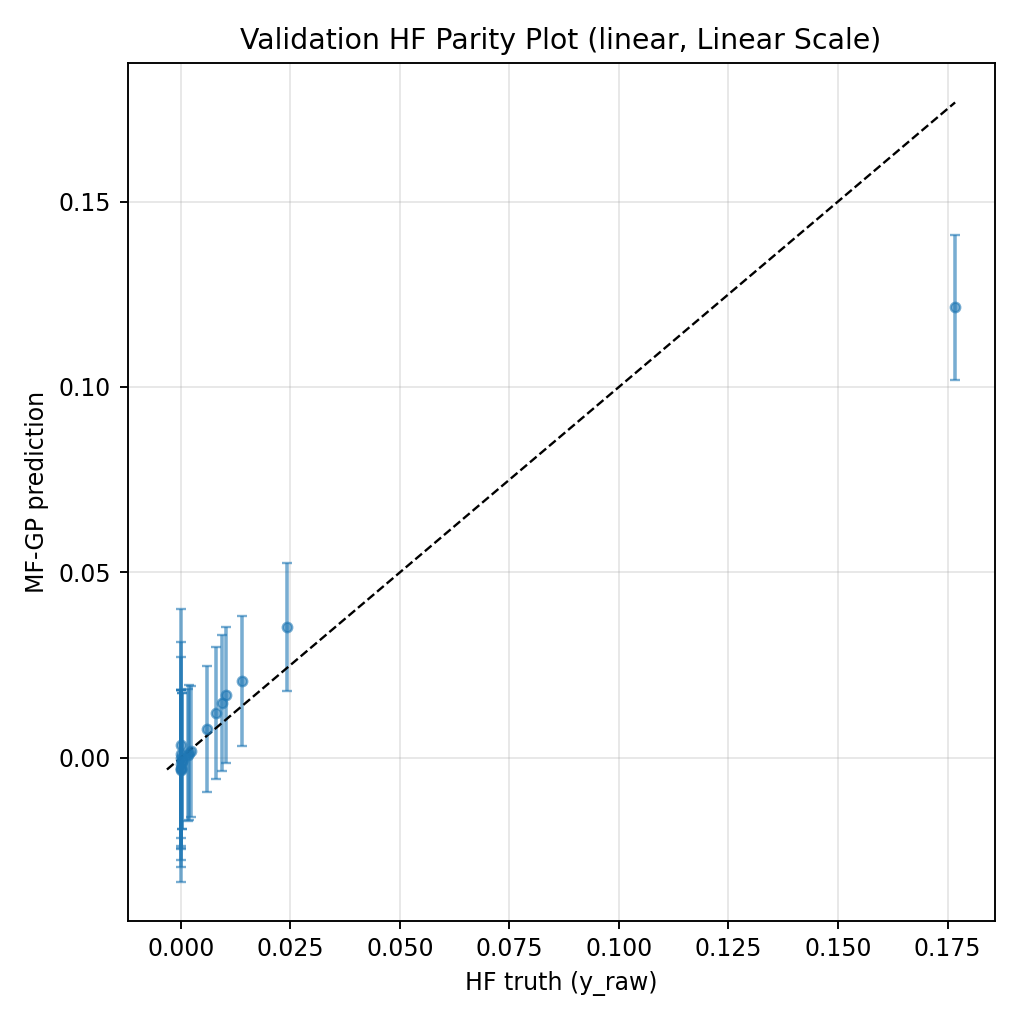

=== Log HF: emulate log10(y_raw) ===
4-fold MF-GP mean/std: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_mean_std_iter0.png


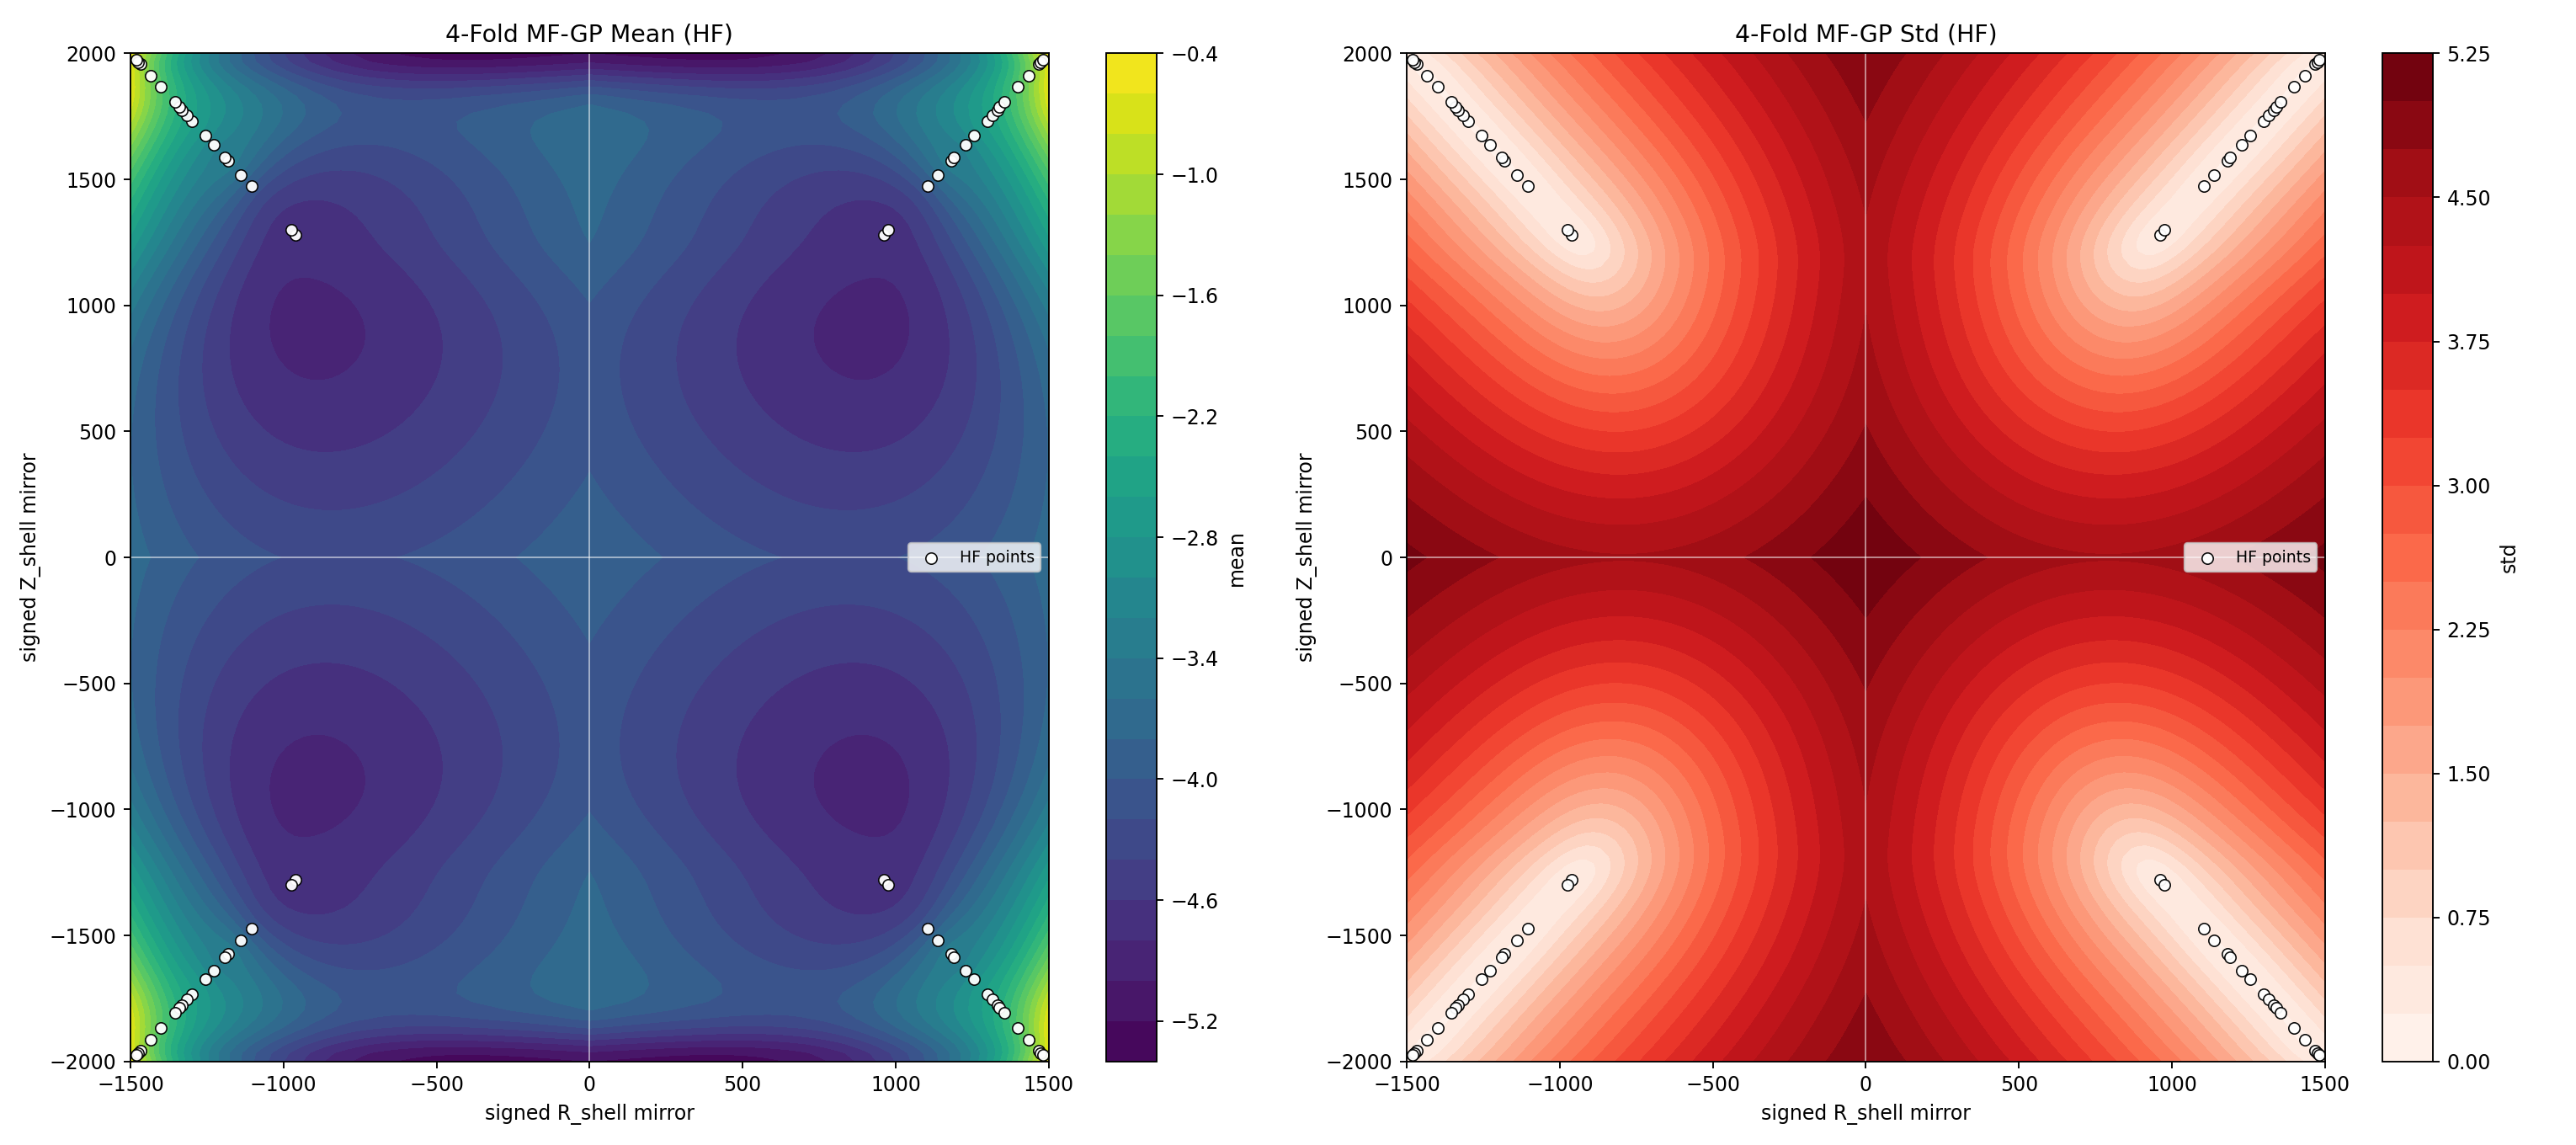

Interactive 3D mean/std HTML: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_hf_validation_across_thetas_linear_iter0.png


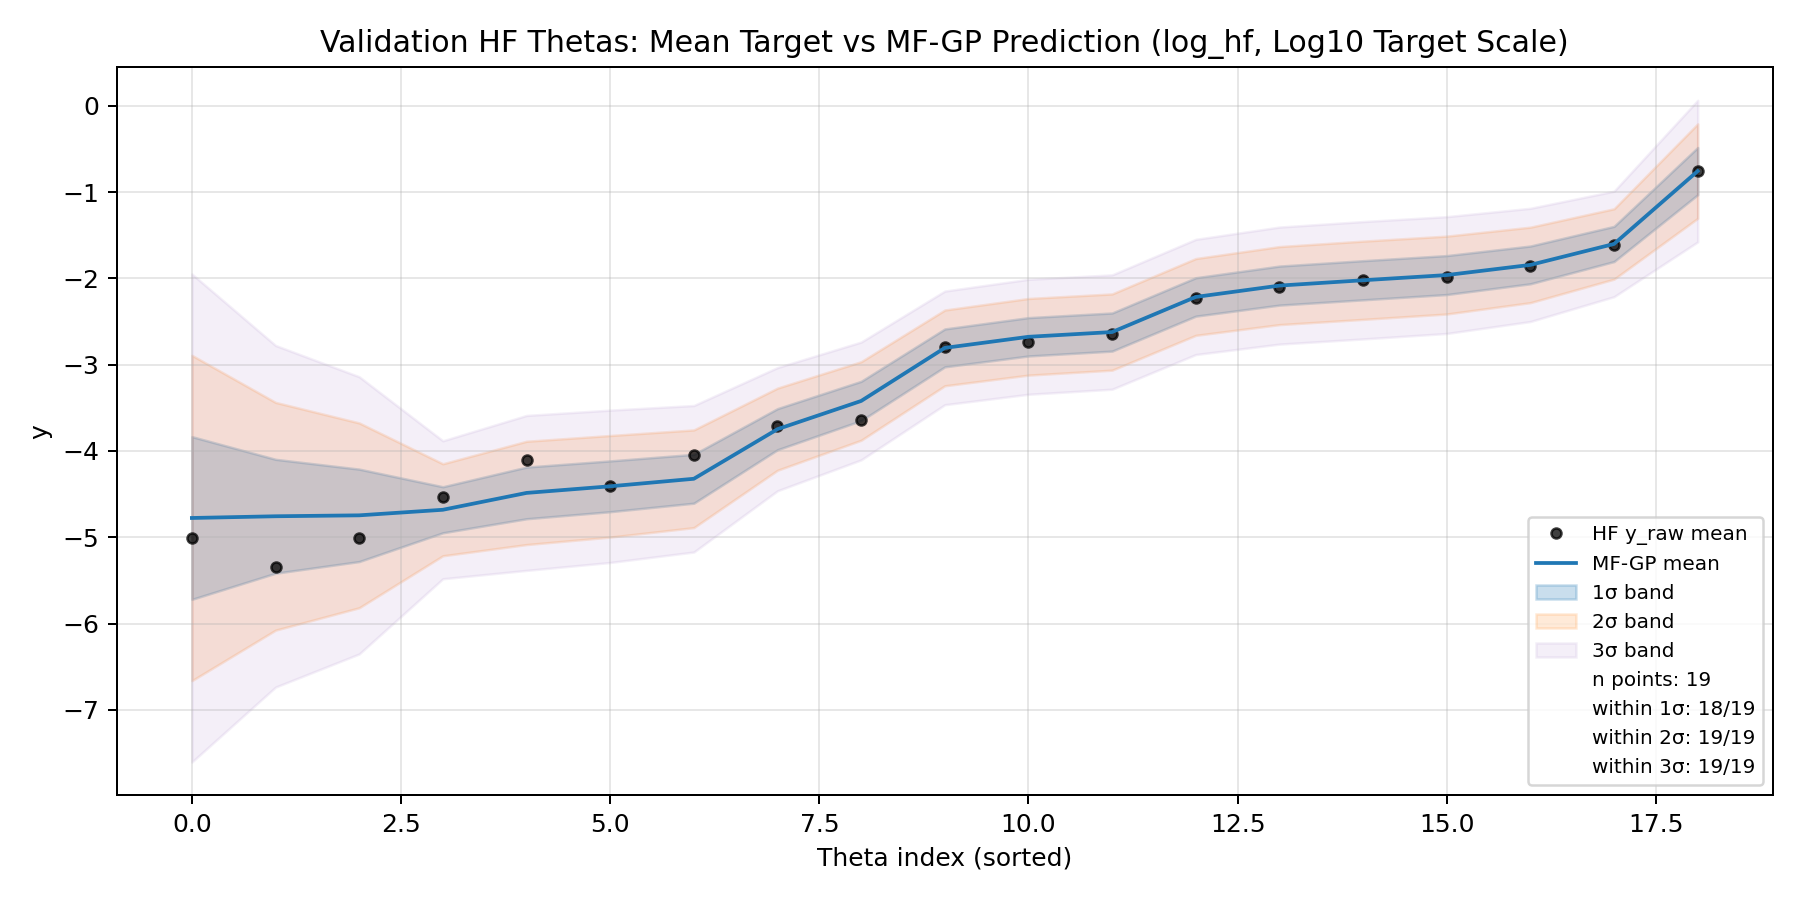

=== Log LF: use log10(y_cnp) ===
4-fold MF-GP mean/std: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_mean_std_iter0.png


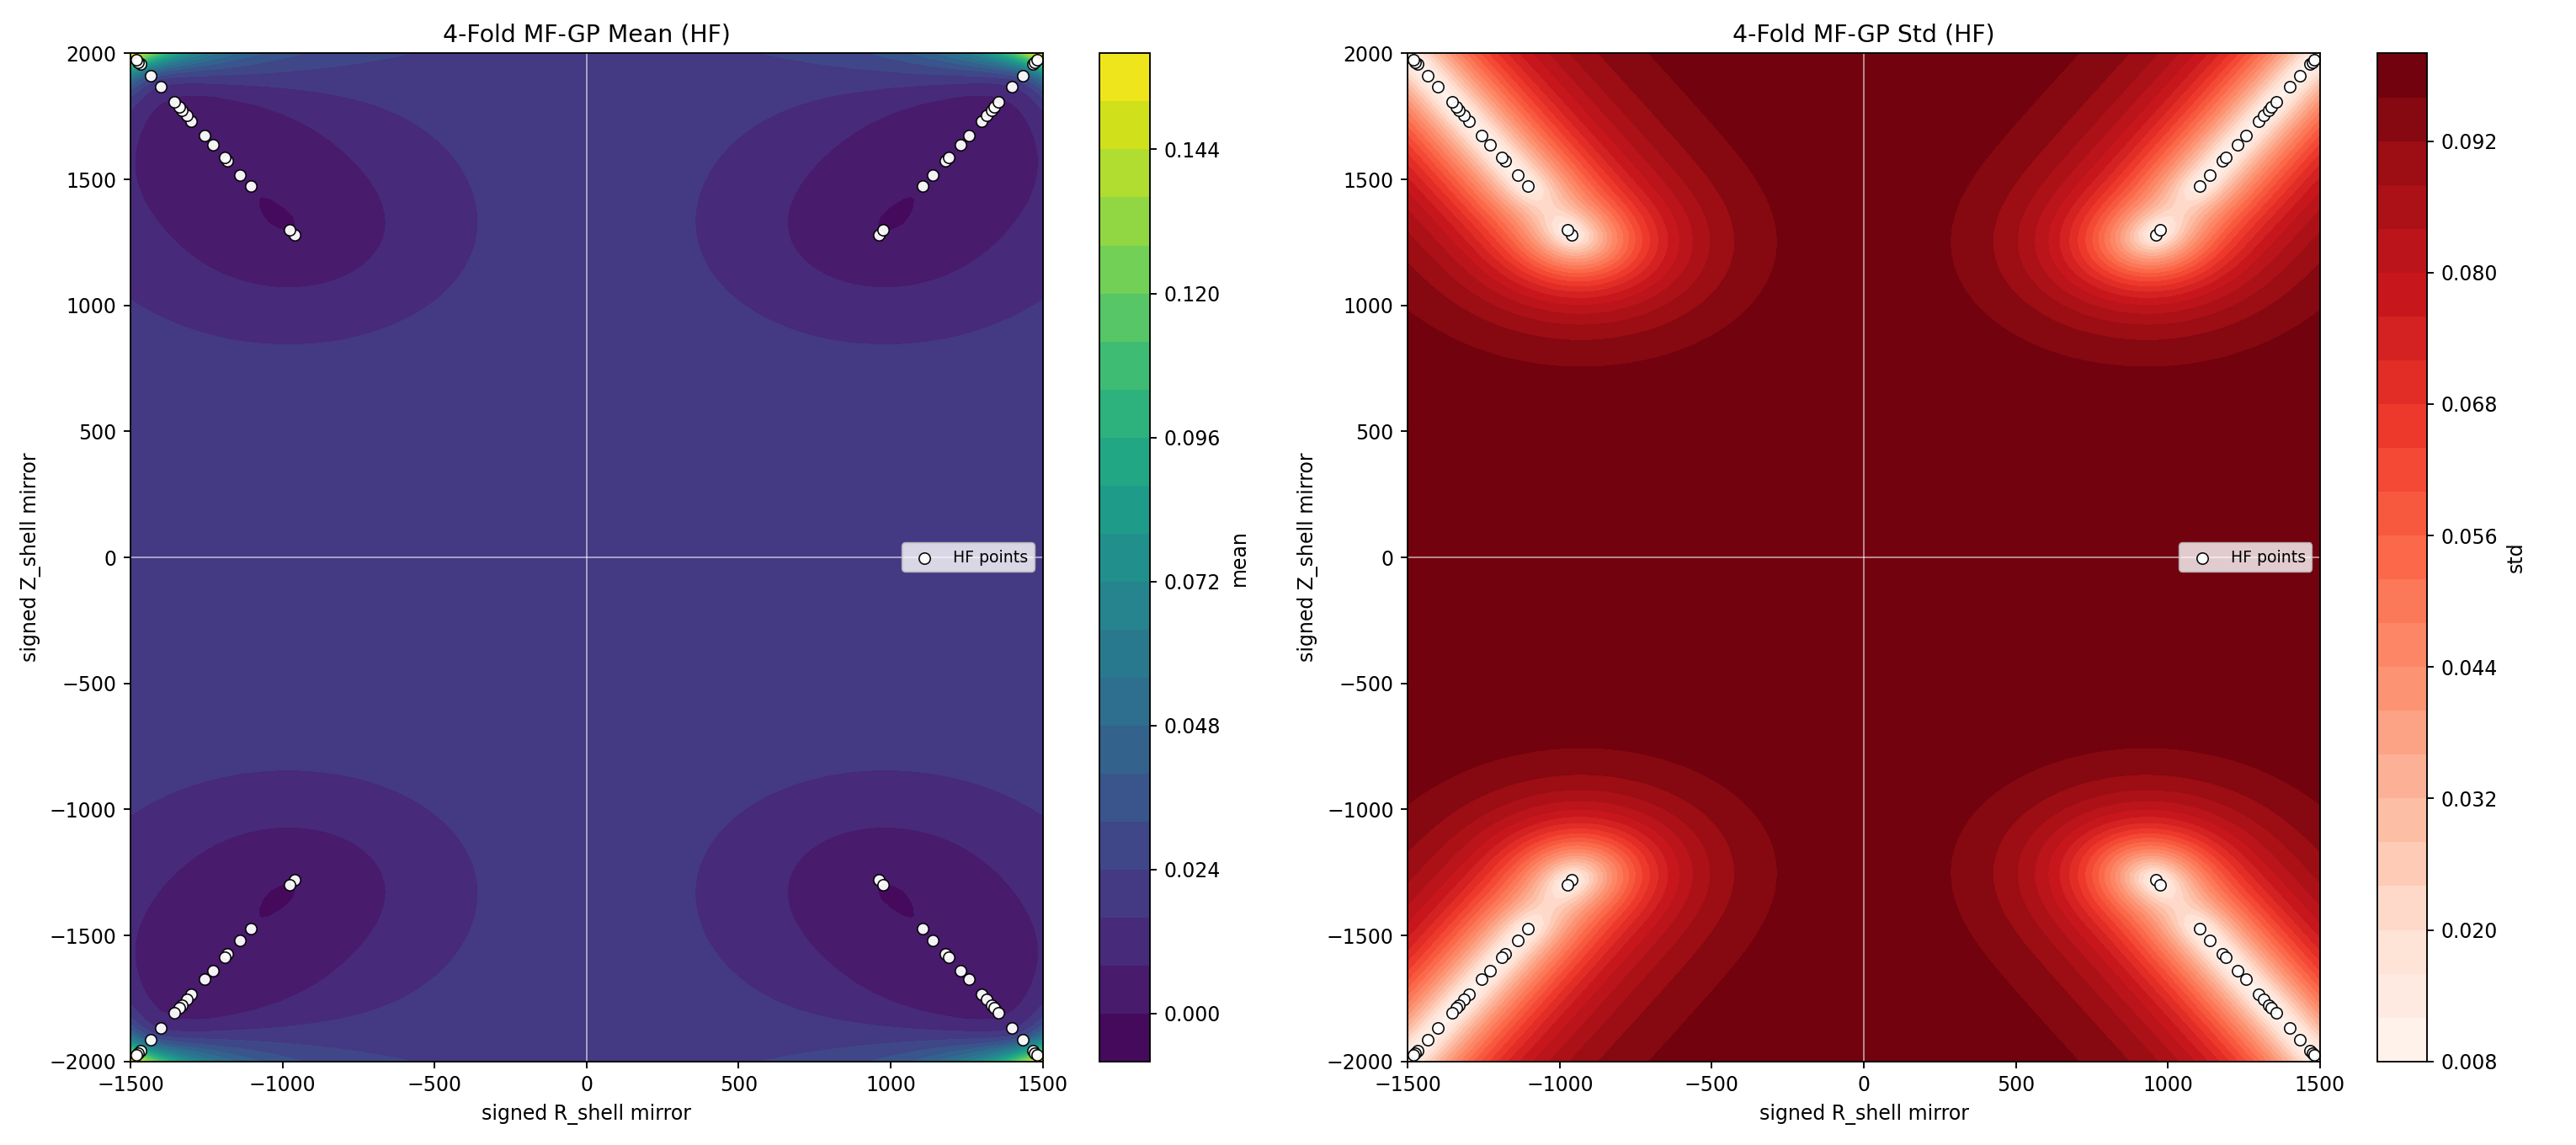

Interactive 3D mean/std HTML: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_across_thetas_linear_iter0.png


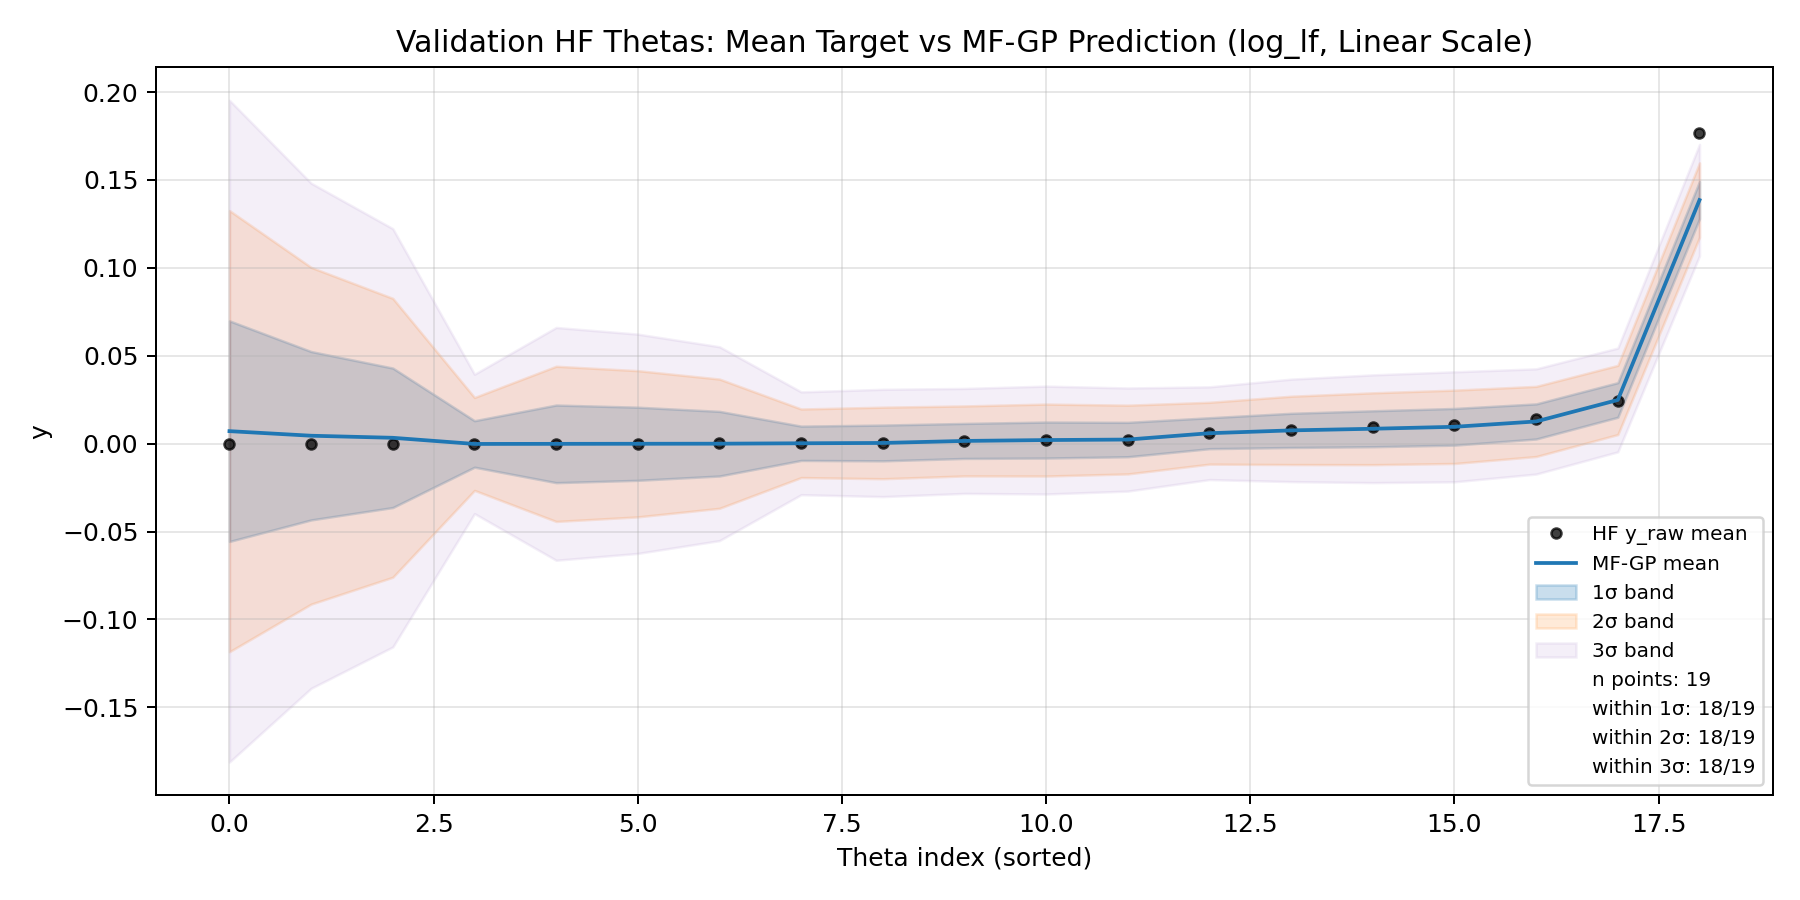

Validation 3-sigma: log10(y) with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_across_thetas_log_linear_sigma_iter0.png


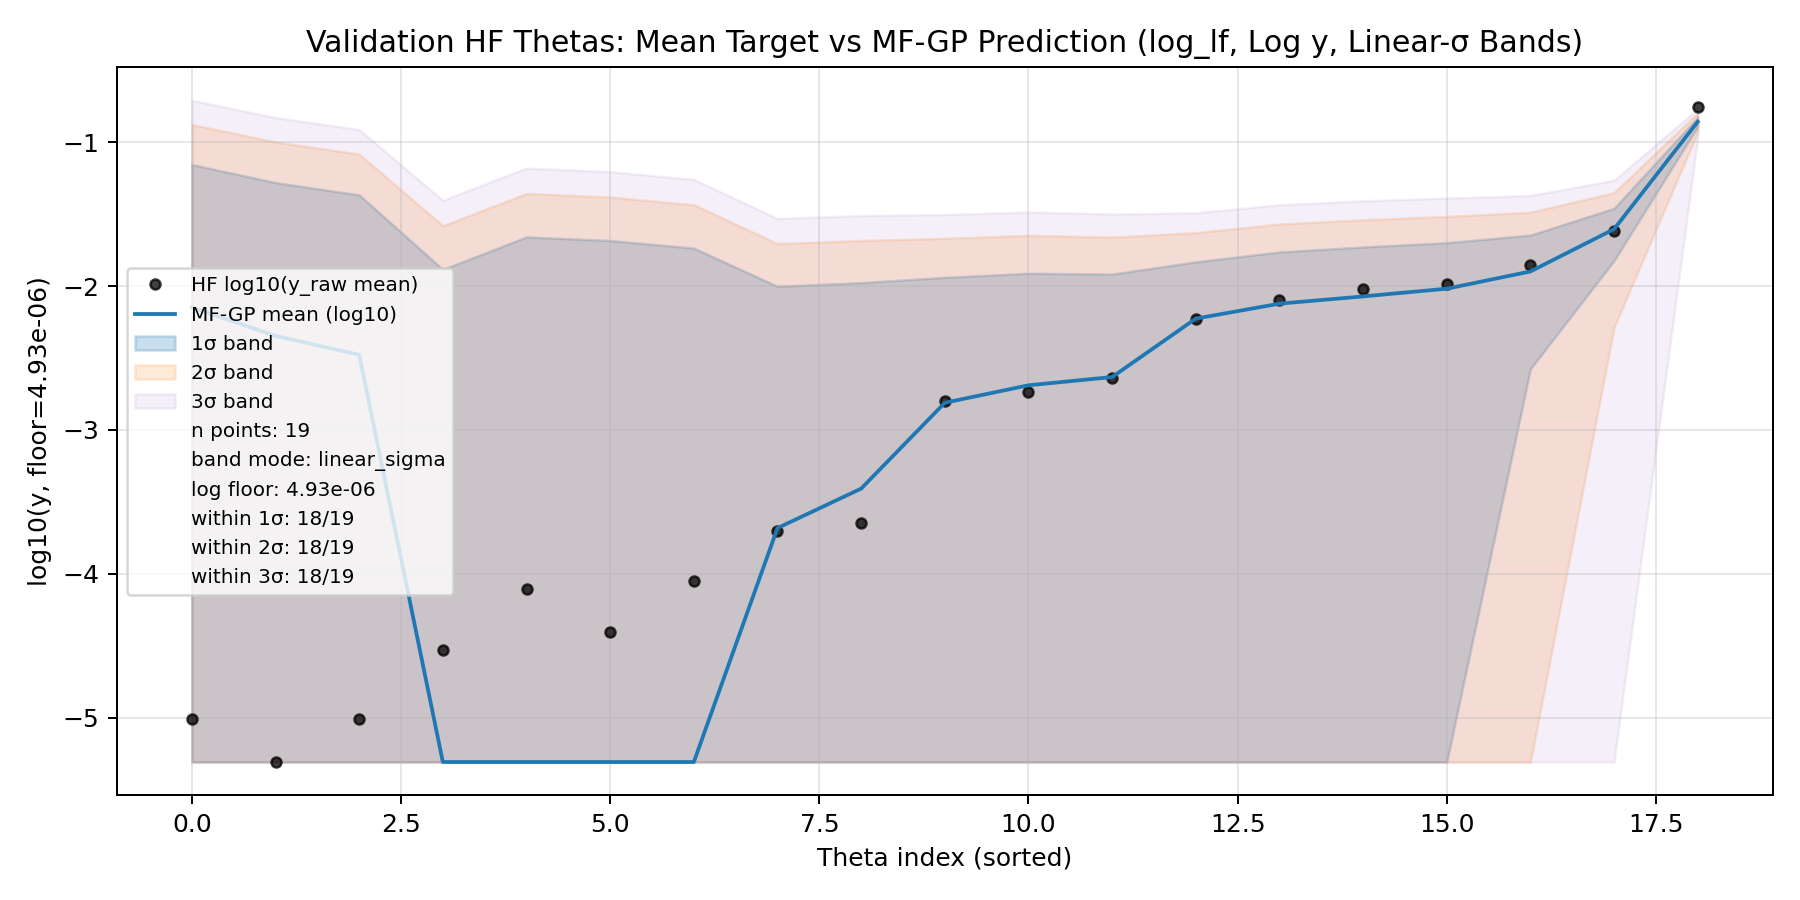

Validation parity: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_lf_validation_parity_linear_iter0.png


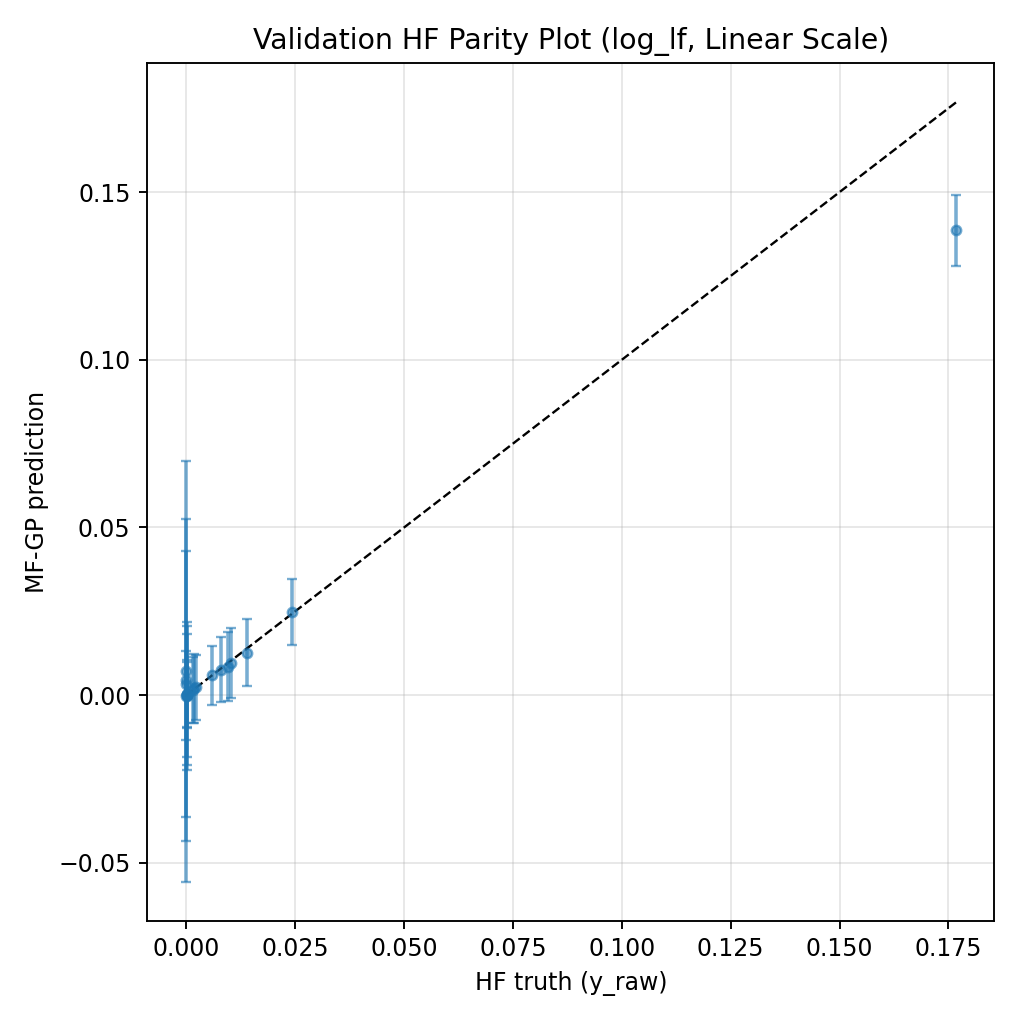

=== Log HF + Log LF: use log10(y_raw) and log10(y_cnp) ===
4-fold MF-GP mean/std: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_mean_std_iter0.png


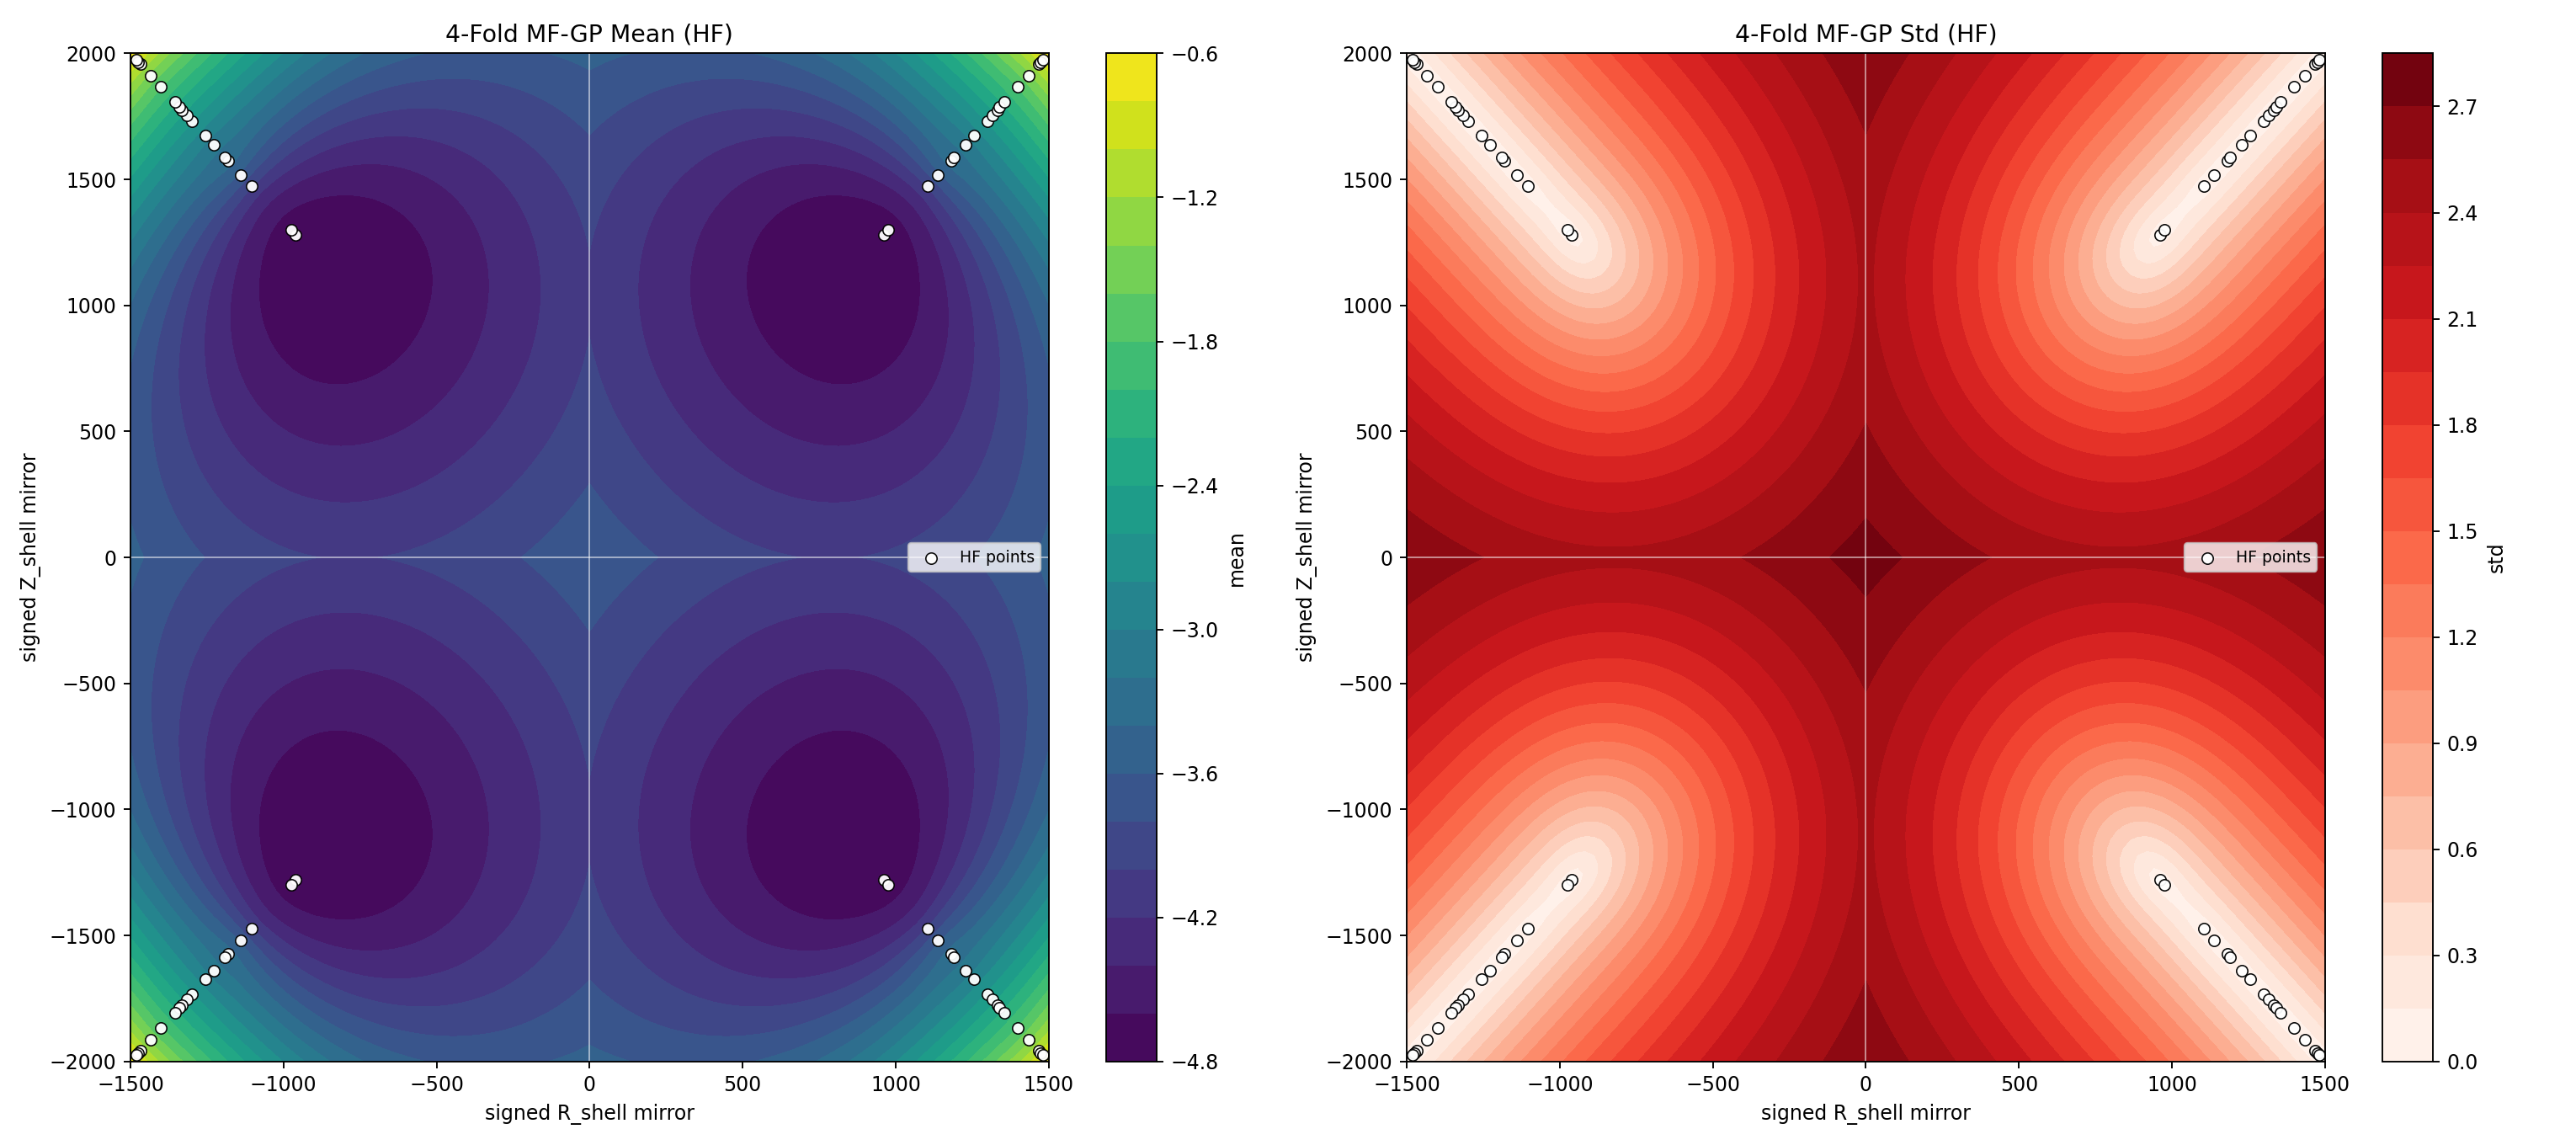

Interactive 3D mean/std HTML: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/klz/Data/XLZD/anpatnaik/data/out/mfgp/mfgp_xlzd_equal_volume_shell_v1_minibatch_log_both_validation_across_thetas_linear_iter0.png


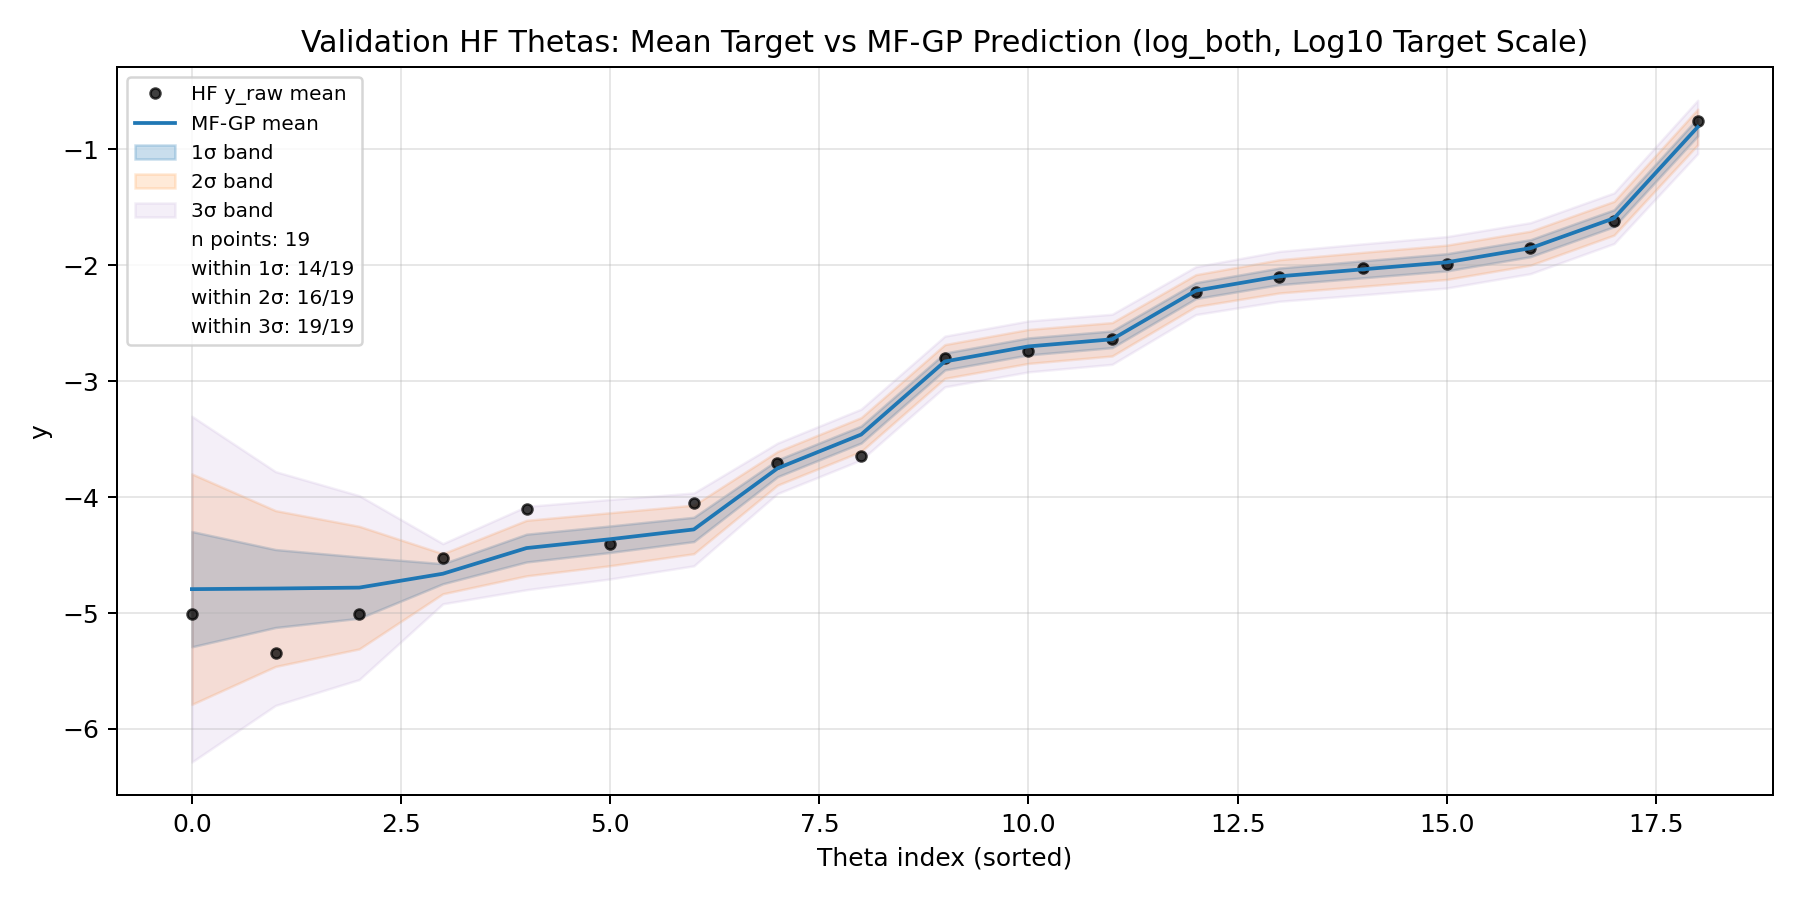

In [9]:
EXPERIMENT_TITLES = {
    "linear": "Normal MF-GP",
    "log_hf": "Log HF: emulate log10(y_raw)",
    "log_lf": "Log LF: use log10(y_cnp)",
    "log_both": "Log HF + Log LF: use log10(y_raw) and log10(y_cnp)",
}

PLOT_SELECTIONS = {
    "linear": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_hf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
    "log_lf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_both": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
}

def show_plot(result, label, key):
    value = getattr(result, key, None)
    if not value:
        return
    print(f"{label}: {value}")
    path = Path(value)
    if path.suffix.lower() == ".png" and path.exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass

for transform in TARGET_TRANSFORMS:
    result = mfgp_results.get(transform)
    if result is None:
        continue
    print(f"=== {EXPERIMENT_TITLES[transform]} ===")
    for label, key in PLOT_SELECTIONS[transform]:
        show_plot(result, label, key)
